# Dependências e Funções

In [1]:
import pandas as pd
import numpy as np

import json

import seaborn as sns
import matplotlib.pyplot as plt
from aeon.datasets import load_regression

from labicompare.visualization import critical_difference_diagram

In [2]:
def initialize_data():
    with open('znorm_results.json') as file:
        results = json.load(file)
    results = sorted(results, key=lambda x: x['dataset'])

    models = list(set(item['model'] for item in results))
    models = models + [name + "_norm" for name in models]
        
    return results, models

def create_table(results, models):
    metrics = pd.DataFrame([], columns=models)
    times = pd.DataFrame([], columns=models)
    aux_dir_rmse = {}
    aux_dir_time = {}
    counter = 0

    for model_dataset in results:
        dataset = model_dataset['dataset']
        model = model_dataset['model']
        rmse = model_dataset['rmse_final']
        time = model_dataset['time_final']
        znorm = model_dataset['znorm']
        
        if znorm == True:
            model += '_norm'
        aux_dir_rmse[model] = rmse
        aux_dir_time[model] = time

        counter += 1

        # São 16 modelos que são subsequentes e dividos por dataset em 'results'.
        if counter % 16 == 0:
            metrics.loc[dataset] = aux_dir_rmse
            times.loc[dataset] = aux_dir_time
            aux_dir_rmse = {}
            aux_dir_time = {}

    return metrics, times

def load_metadata():
    metadata_df = (pd.read_csv('datasets_metadata.csv')).set_index('dataset')

    return metadata_df

def normalize_rmse(dataset_name, rmse_value, datasets_stats):
    y = datasets_stats.loc[dataset_name]

    return rmse_value / (y['max'] - y['min'])

def meta_model_pair_plot(metrics, metadata_df, datasets_stats, same_y_scale=False):
    '''
    Returns the Pair-plot between the metadata of the datasets used in model
    training and the results (metrics) of it.
    
    Args :
        metrics (pd.DataFrame): results of each model (columns) in each dataset (rows).
        metadata_df (pd.DataFrame): values of each type of metadata (columns) of each dataset (rows).
        same_y_scale (bool): If True, all plots in the same row will have the same y-axis scale.

    Returns:
        fig (matplotlib.figure.Figure): the object of the figure containing all
            components created to generate the meta-model pair-plot.
        ax (matplotlib.pyplot.axes): last axes used to create the meta-model pair-plot.
    '''
    
    # Define number of rows and columns dynamically.
    models = list(metrics.columns)
    metadata = list(metadata_df.columns)

    num_rows = len(metadata)
    num_columns = len(models)

    # Create figure and subplots.
    fig, axs = plt.subplots(num_rows, num_columns, figsize=(num_columns * 5, num_rows * 5))
    
    # Store y-axis limits if same_y_scale is True.
    if same_y_scale:
        y_min = {}
        y_max = {}
        for i in range(num_rows):
            all_y_values = []
            for j in range(num_columns):
                cur_model = models[j]
                model_metrics = metrics[cur_model].copy()
                for dataset in model_metrics.index:
                    model_metrics[dataset] = normalize_rmse(dataset, model_metrics[dataset], datasets_stats)
                all_y_values.extend(model_metrics.values)
            y_min[i] = min(all_y_values)
            y_max[i] = max(all_y_values)


    colors = ['r', 'g', 'b', 'y']
    
    # Plot on subplots.
    for i in range(num_rows):
        cur_meta = metadata[i]
        metadata_values = metadata_df[cur_meta]

        for j in range(num_columns):
            cur_model = models[j]
            model_metrics = metrics[cur_model].copy()
            
            for dataset in model_metrics.index:
                model_metrics[dataset] = normalize_rmse(dataset, model_metrics[dataset], datasets_stats)
            
            # Create a Pandas DataFrame from the dictionaries.
            df = pd.DataFrame({
                'dataset': list(metadata_values.keys()),
                cur_meta: list(metadata_values.values),
                'RMSE': list(model_metrics.values)
            })
            
            # Ensure axes limits are adaptive with padding.
            ax = axs[i, j] if num_rows > 1 and num_columns > 1 else axs[max(i, j)]
            sns.scatterplot(x=cur_meta, y='RMSE', data=df, ax=ax, alpha=0.5, color=colors[i])
            x_padding = (df[cur_meta].max() - df[cur_meta].min()) * 0.1
            y_padding = (df['RMSE'].max() - df['RMSE'].min()) * 0.1
            ax.set_xlim(df[cur_meta].min() - x_padding, df[cur_meta].max() + x_padding)
            
            if same_y_scale:
                ax.set_ylim(y_min[i] - y_padding, y_max[i] + y_padding)
            else:
                ax.set_ylim(df['RMSE'].min() - y_padding, df['RMSE'].max() + y_padding)
            
            if i == 0:
                ax.set_title(cur_model, fontsize=14)
            
            ax.set_xlabel("")
            ax.set_ylabel("")
            if j == 0:
                ax.set_ylabel(cur_meta, fontsize=14)

    # Adjust layout.
    plt.tight_layout(pad=2)
    
    return fig, ax

def get_specific_metrics(metrics, dropout='useless', znorm='useless', architectures=[]):
    aux_metrics = metrics

    # Select dropout and znorm data.
    if dropout != 'useless':
        if dropout:
            aux_metrics = aux_metrics.drop(columns=[col for col in aux_metrics.columns if not "_do" in col])
        elif not dropout:
            aux_metrics = aux_metrics.drop(columns=[col for col in aux_metrics.columns if  "_do" in col])
    if znorm != 'useless':
        if znorm:
            aux_metrics = aux_metrics.drop(columns=[col for col in aux_metrics.columns if not "_norm" in col])
        elif not znorm:
            aux_metrics = aux_metrics.drop(columns=[col for col in aux_metrics.columns if "_norm" in col])

    # Select architectures data.
    if architectures != []:
        for col in aux_metrics.columns:
            col_arch = (col.replace('_do','')).replace('_norm','')

            used = False
            for arch in architectures:
                if arch == col_arch:
                    used = True
                    break

            if not used:
                aux_metrics = aux_metrics.drop(columns=col)

    return aux_metrics

def plot_rmse_per_dataset(metrics, paint_factor):
    
    for dataset in list(metrics.index):
        df = metrics.loc[[dataset]].T
        df.rename(columns={dataset: 'rmse'}, inplace=True)
        df['model'] = df.index
        df.reset_index(drop=True, inplace=True)

        df = df.sort_values(by="rmse", ascending=False)

        # Definindo cores com base na presença de paint_factor no nome do modelo
        df["color"] = df["model"].apply(lambda x: "red" if paint_factor in x else "blue")

        # Criando o histograma
        plt.figure(figsize=(12, 6))
        sns.barplot(x="rmse", y="model", data=df, hue="model", palette=df["color"].tolist(), legend=False)

        plt.title(dataset)

# Carregando os dados

In [3]:
results, models = initialize_data()
metrics, times = create_table(results, models)

In [4]:
metadata_df = load_metadata()
datasets_stats = (pd.read_csv('datasets_stats.csv')).set_index('dataset')

# Plotando

## Comparação geral (Wilcoxon)

In [51]:
cols = ['FCN_biggerKernels','FCN_moreKernels','FCN_moreLayers','FCN']
bepe_set = metrics.drop(columns=list(set(metrics.columns) - set(cols)))

In [52]:
bepe_set

,FCN_biggerKernels,FCN_moreKernels,FCN_moreLayers,FCN
AppliancesEnergy,4.063261,3.927943,3.701141,4.408596
AustraliaRainfall,12.788309,12.821235,12.836689,12.820823
BeijingPM10Quality,69.740870,70.089038,66.535278,70.459634
BeijingPM25Quality,44.736903,45.204549,42.016107,45.883605
BenzeneConcentration,0.086488,0.073974,0.093347,0.082191
Covid3Month,0.045677,0.041952,0.044605,0.043293
FloodModeling1,0.005595,0.005487,0.005651,0.005840
FloodModeling2,0.004026,0.005055,0.003594,0.004818
HouseholdPowerConsumption1,99.668624,99.488025,97.640273,106.609828
HouseholdPowerConsumption2,34.316114,33.334310,34.901091,33.160757


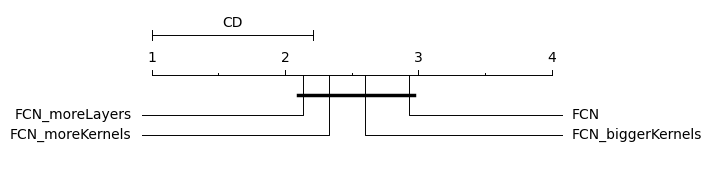

In [53]:
data = -bepe_set
fig = critical_difference_diagram(
    metrics=data,
    test='nemenyi',
    alpha=0.05
)

### Comparação de desempenho (RMSE)

Index(['FCN_moreLayers_do', 'FCN_moreKernels_do', 'FCN_biggerKernels_do',
       'FCN_do', 'FCN_moreLayers_do_norm', 'FCN_moreKernels_do_norm',
       'FCN_do_norm', 'FCN_norm', 'FCN_biggerKernels_do_norm',
       'FCN_moreLayers_norm', 'FCN_moreKernels_norm', 'FCN_biggerKernels_norm',
       'FCN_biggerKernels', 'FCN', 'FCN_moreKernels', 'FCN_moreLayers'],
      dtype='object')
[4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 1, 2, 3, 0]
[4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 1, 2, 3, 12]
[4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 12]


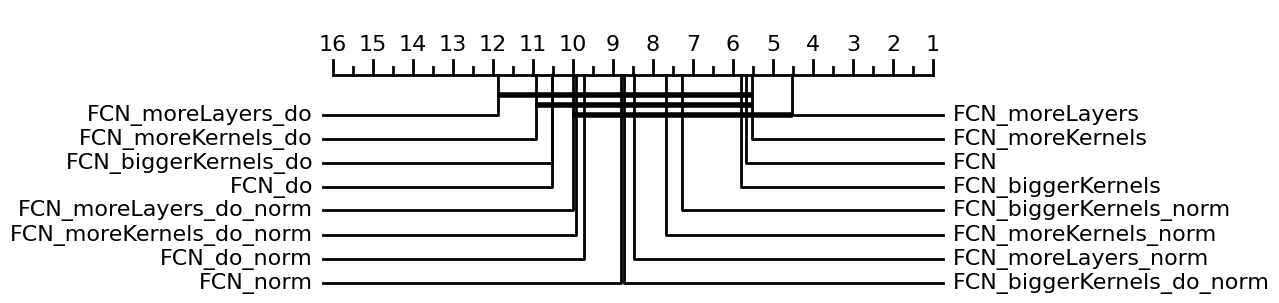

In [46]:
data = -metrics
fig = critical_difference_diagram(
    metrics=data,
    test='wilcoxon',
    alpha=0.05
)

Index(['FCN_moreLayers', 'FCN_biggerKernels', 'FCN_moreKernels', 'FCN',
       'FCN_biggerKernels_do', 'FCN_do', 'FCN_moreKernels_do',
       'FCN_moreLayers_do'],
      dtype='object')
[3, 1, 2, 0]
[3, 1, 2, 4, 5, 6]
[3, 7, 4, 5, 6]


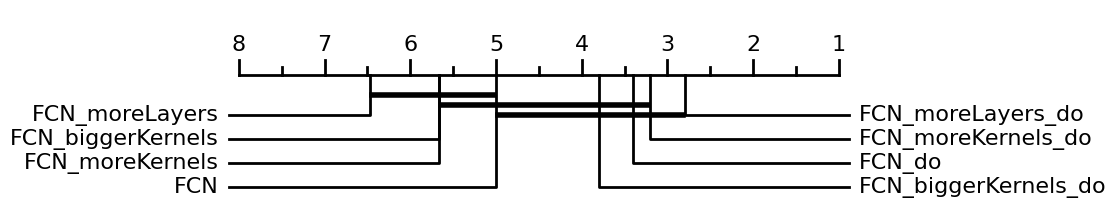

In [6]:
data = get_specific_metrics(metrics, znorm=False)
fig = critical_difference_diagram(
    metrics=data,
    test='wilcoxon',
    alpha=0.05
)

Index(['FCN_biggerKernels_norm', 'FCN_moreKernels_norm', 'FCN_moreLayers_norm',
       'FCN_norm', 'FCN_biggerKernels_do_norm', 'FCN_do_norm',
       'FCN_moreKernels_do_norm', 'FCN_moreLayers_do_norm'],
      dtype='object')
[2, 4, 5, 6, 1, 0]
[2, 4, 5, 6, 1, 3]
[2, 4, 5, 6, 7, 3]


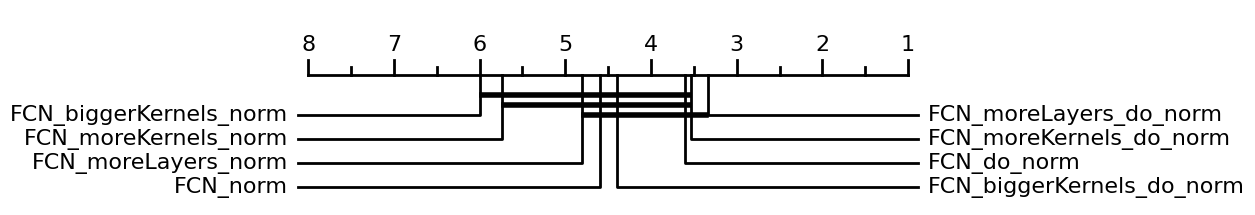

In [7]:
data = get_specific_metrics(metrics, znorm=True)
fig = critical_difference_diagram(
    metrics=data,
    test='wilcoxon',
    alpha=0.05
)

Index(['FCN_moreLayers', 'FCN_moreKernels', 'FCN_biggerKernels', 'FCN',
       'FCN_biggerKernels_norm', 'FCN_moreLayers_norm', 'FCN_moreKernels_norm',
       'FCN_norm'],
      dtype='object')
[0, 1, 2, 3, 5, 6, 4]
[0, 1, 2, 3, 5, 6, 7]


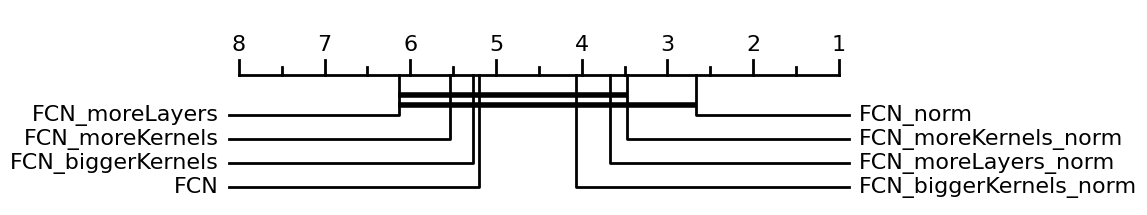

In [8]:
data = get_specific_metrics(metrics, dropout=False)
fig = critical_difference_diagram(
    metrics=data,
    test='wilcoxon',
    alpha=0.05
)

In [9]:
# data = get_specific_metrics(metrics, dropout=True)
# fig = critical_difference_diagram(
#     metrics=data,
#     test='wilcoxon',
#     alpha=0.05
# )

A análise acima dá errado pois todos são estaticamente iguais

### Comparação de tempo

Index(['FCN_do', 'FCN_biggerKernels_do', 'FCN_norm',
       'FCN_biggerKernels_do_norm', 'FCN', 'FCN_do_norm',
       'FCN_biggerKernels_norm', 'FCN_moreKernels_do', 'FCN_biggerKernels',
       'FCN_moreKernels_do_norm', 'FCN_moreKernels_norm', 'FCN_moreLayers_do',
       'FCN_moreLayers_do_norm', 'FCN_moreLayers_norm', 'FCN_moreKernels',
       'FCN_moreLayers'],
      dtype='object')
[0, 1, 2, 3, 5, 6, 7, 9, 11, 12, 13, 8, 10, 4]
[0, 1, 2, 3, 5, 6, 7, 9, 11, 12, 13, 8, 10, 14]
[0, 1, 2, 3, 5, 6, 7, 9, 11, 12, 13, 15, 14]


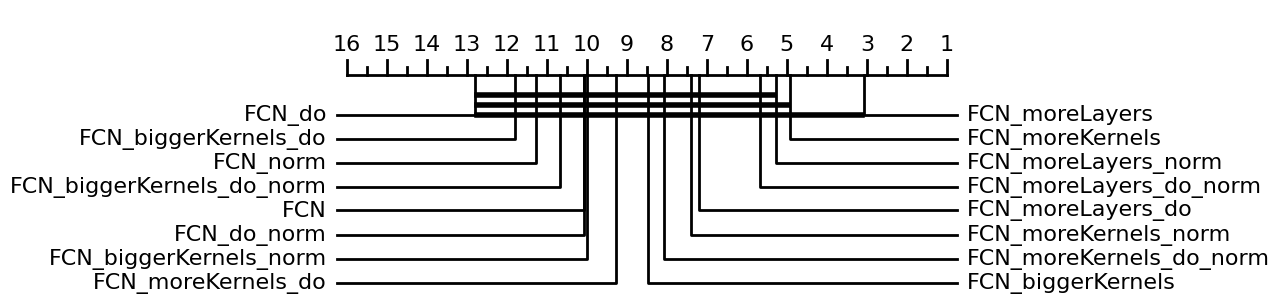

In [10]:
fig = critical_difference_diagram(
    metrics=times,
    test='wilcoxon',
    alpha=0.05
)

Index(['FCN_do', 'FCN_biggerKernels_do', 'FCN', 'FCN_biggerKernels',
       'FCN_moreKernels_do', 'FCN_moreLayers_do', 'FCN_moreKernels',
       'FCN_moreLayers'],
      dtype='object')
[0, 1, 4, 5, 2, 3]
[0, 1, 4, 5, 6]
[0, 1, 4, 5, 7]


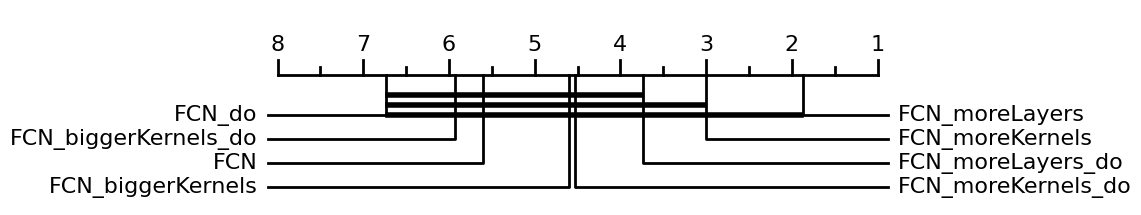

In [11]:
data = get_specific_metrics(times, znorm=False)
fig = critical_difference_diagram(
    metrics=data,
    test='wilcoxon',
    alpha=0.05
)

Index(['FCN_norm', 'FCN_biggerKernels_do_norm', 'FCN_do_norm',
       'FCN_biggerKernels_norm', 'FCN_moreKernels_do_norm',
       'FCN_moreKernels_norm', 'FCN_moreLayers_do_norm',
       'FCN_moreLayers_norm'],
      dtype='object')
[0, 1, 2, 3, 4, 5, 6, 7]


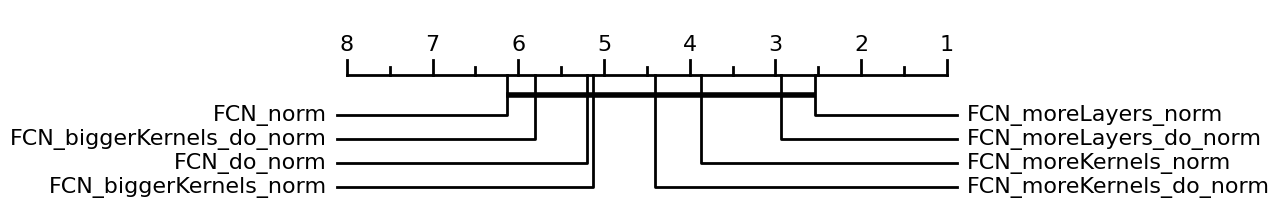

In [12]:
data = get_specific_metrics(times, znorm=True)
fig = critical_difference_diagram(
    metrics=data,
    test='wilcoxon',
    alpha=0.05
)

Index(['FCN_norm', 'FCN', 'FCN_biggerKernels_norm', 'FCN_biggerKernels',
       'FCN_moreKernels_norm', 'FCN_moreLayers_norm', 'FCN_moreKernels',
       'FCN_moreLayers'],
      dtype='object')
[0, 2, 4, 1, 3]
[0, 2, 4, 6]
[0, 2, 7]
[0, 5, 4, 1, 3]
[0, 5, 4, 6]
[0, 5, 7]


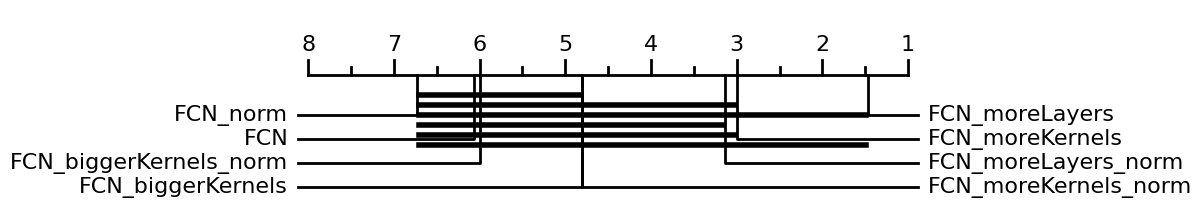

In [13]:
data = get_specific_metrics(times, dropout=False)
fig = critical_difference_diagram(
    metrics=data,
    test='wilcoxon',
    alpha=0.05
)

Index(['FCN_do', 'FCN_biggerKernels_do', 'FCN_biggerKernels_do_norm',
       'FCN_do_norm', 'FCN_moreKernels_do', 'FCN_moreKernels_do_norm',
       'FCN_moreLayers_do', 'FCN_moreLayers_do_norm'],
      dtype='object')
[0, 1, 2, 3, 4, 5, 6, 7]


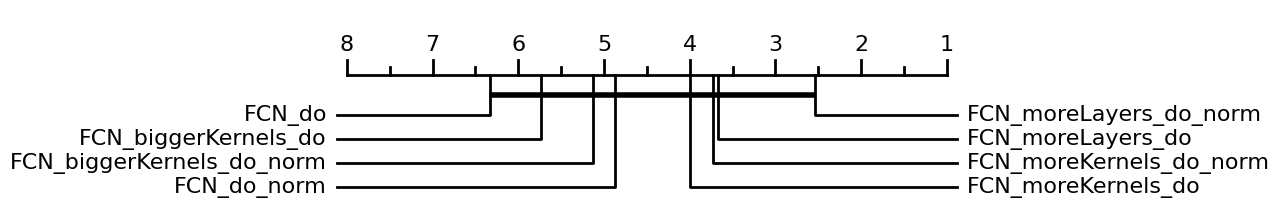

In [14]:
data = get_specific_metrics(times, dropout=True)
fig = critical_difference_diagram(
    metrics=data,
    test='wilcoxon',
    alpha=0.05
)

## Comparação usando metadados (pair-plot)

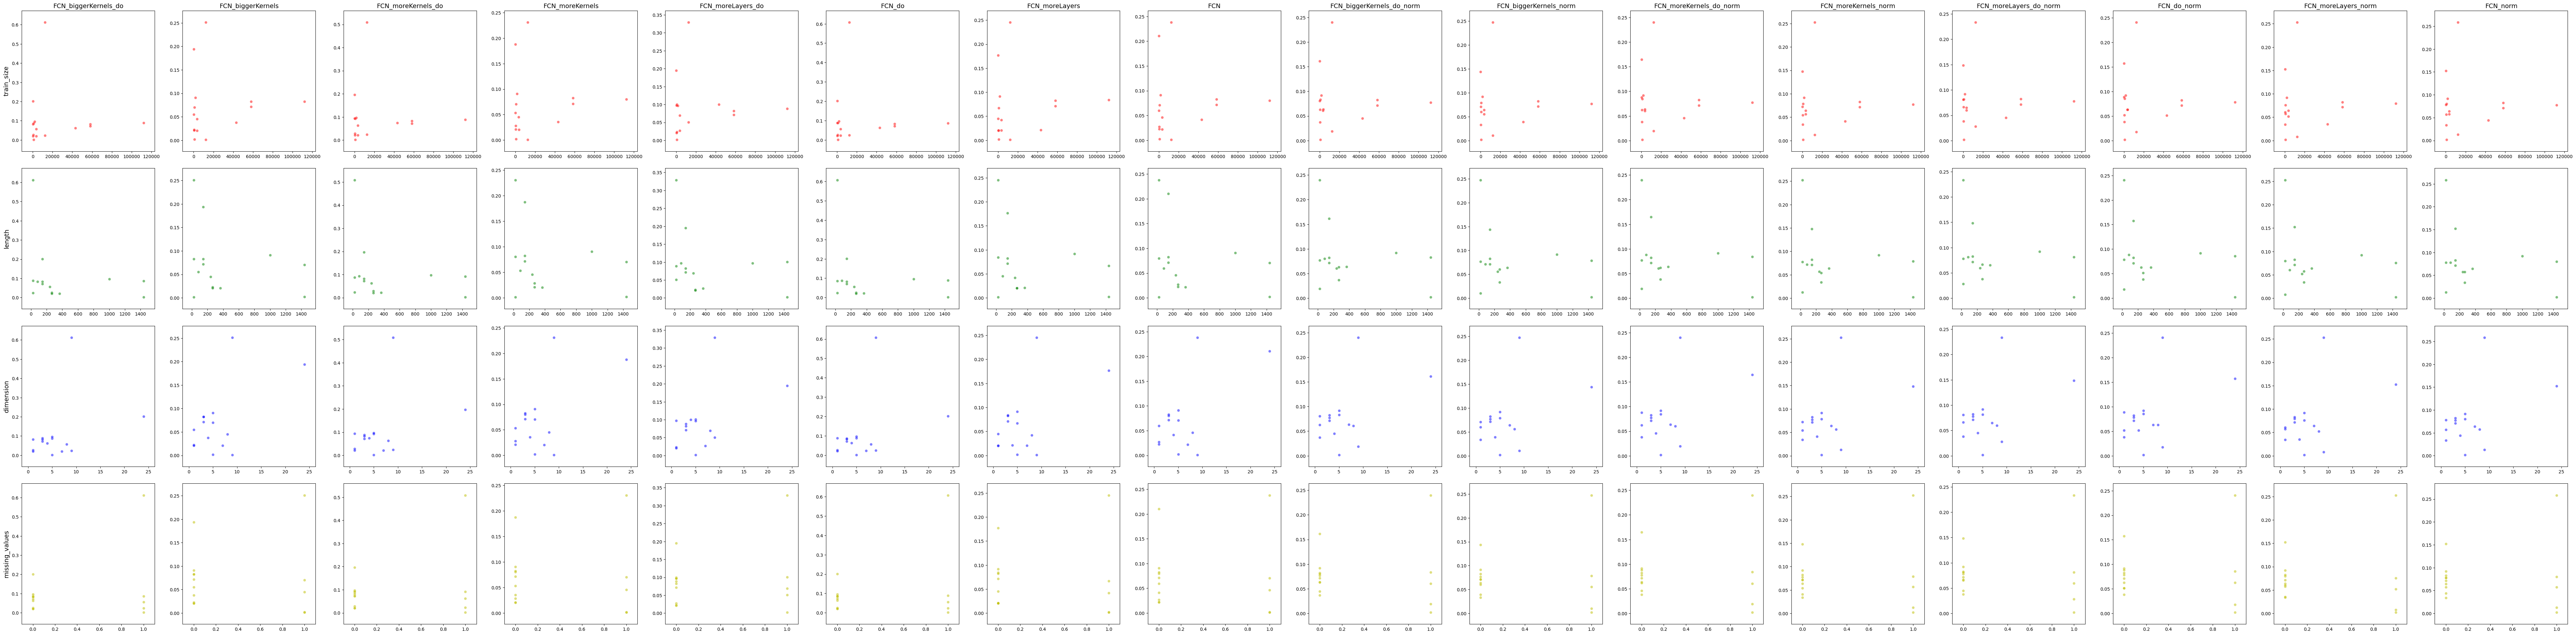

In [15]:
data = metrics
fig = meta_model_pair_plot(data, metadata_df, datasets_stats, same_y_scale=False)

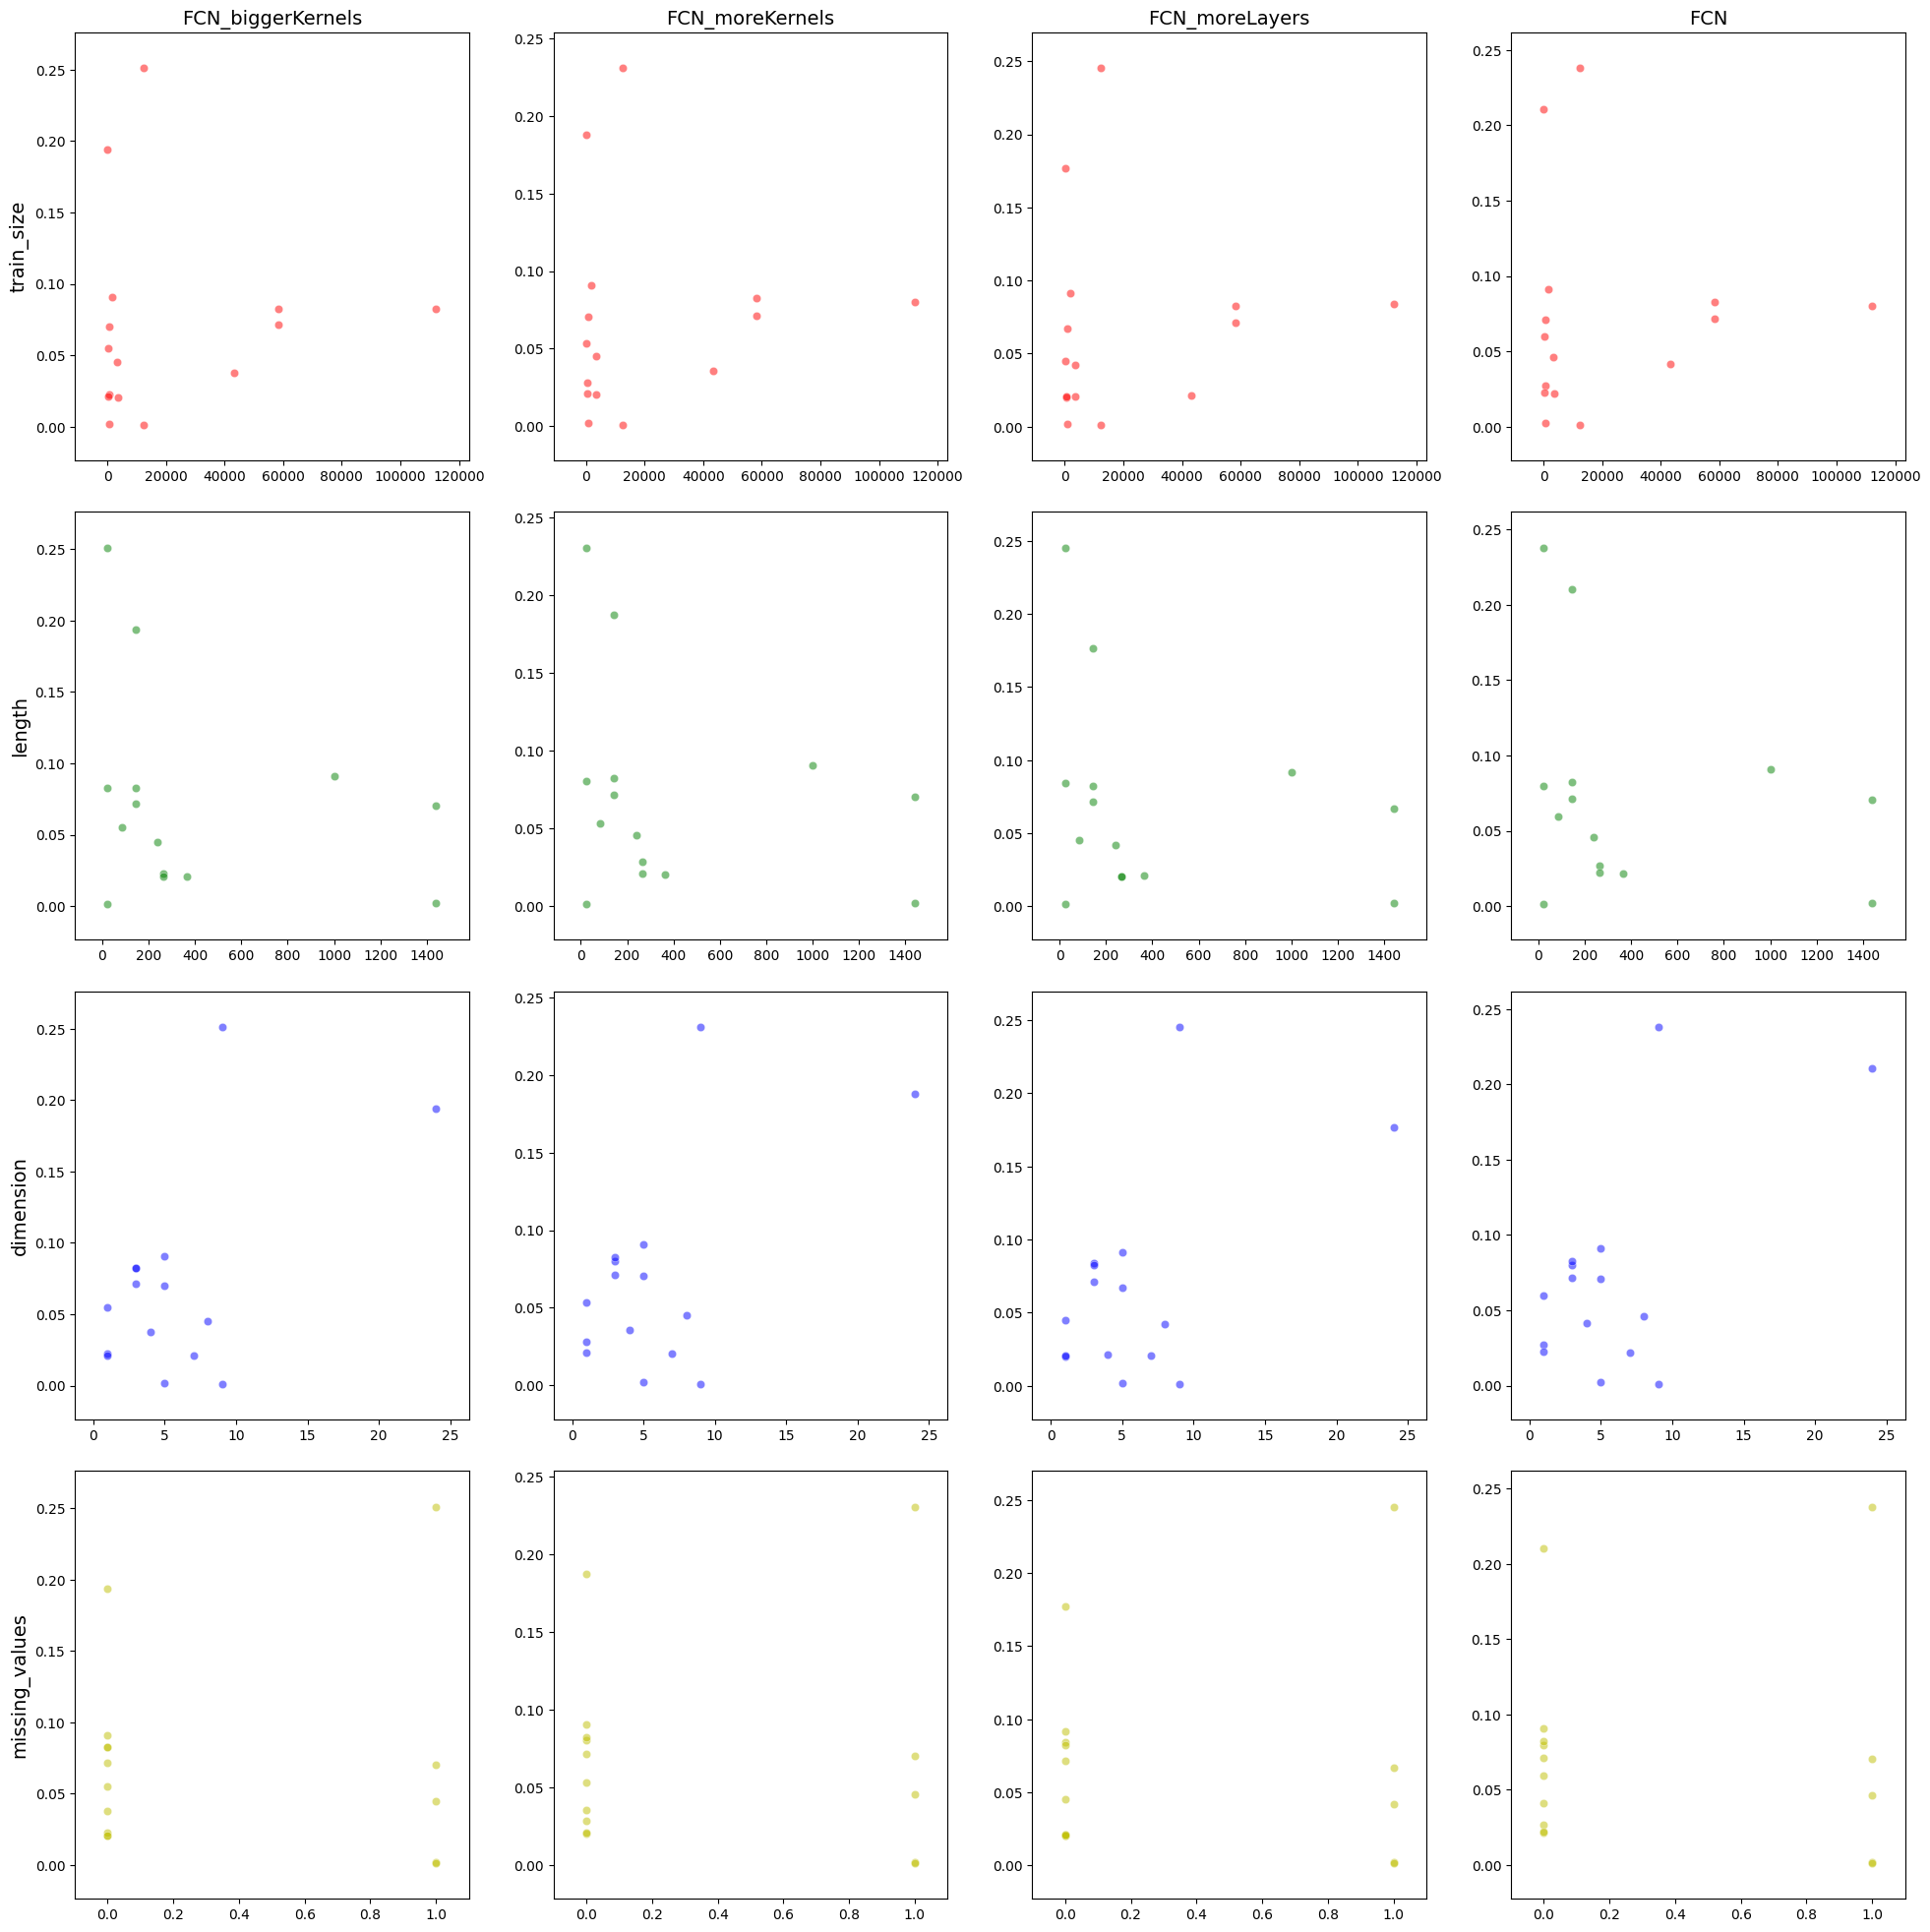

In [16]:
data = get_specific_metrics(metrics, dropout=False, znorm=False)
fig = meta_model_pair_plot(data, metadata_df, datasets_stats, same_y_scale=False)

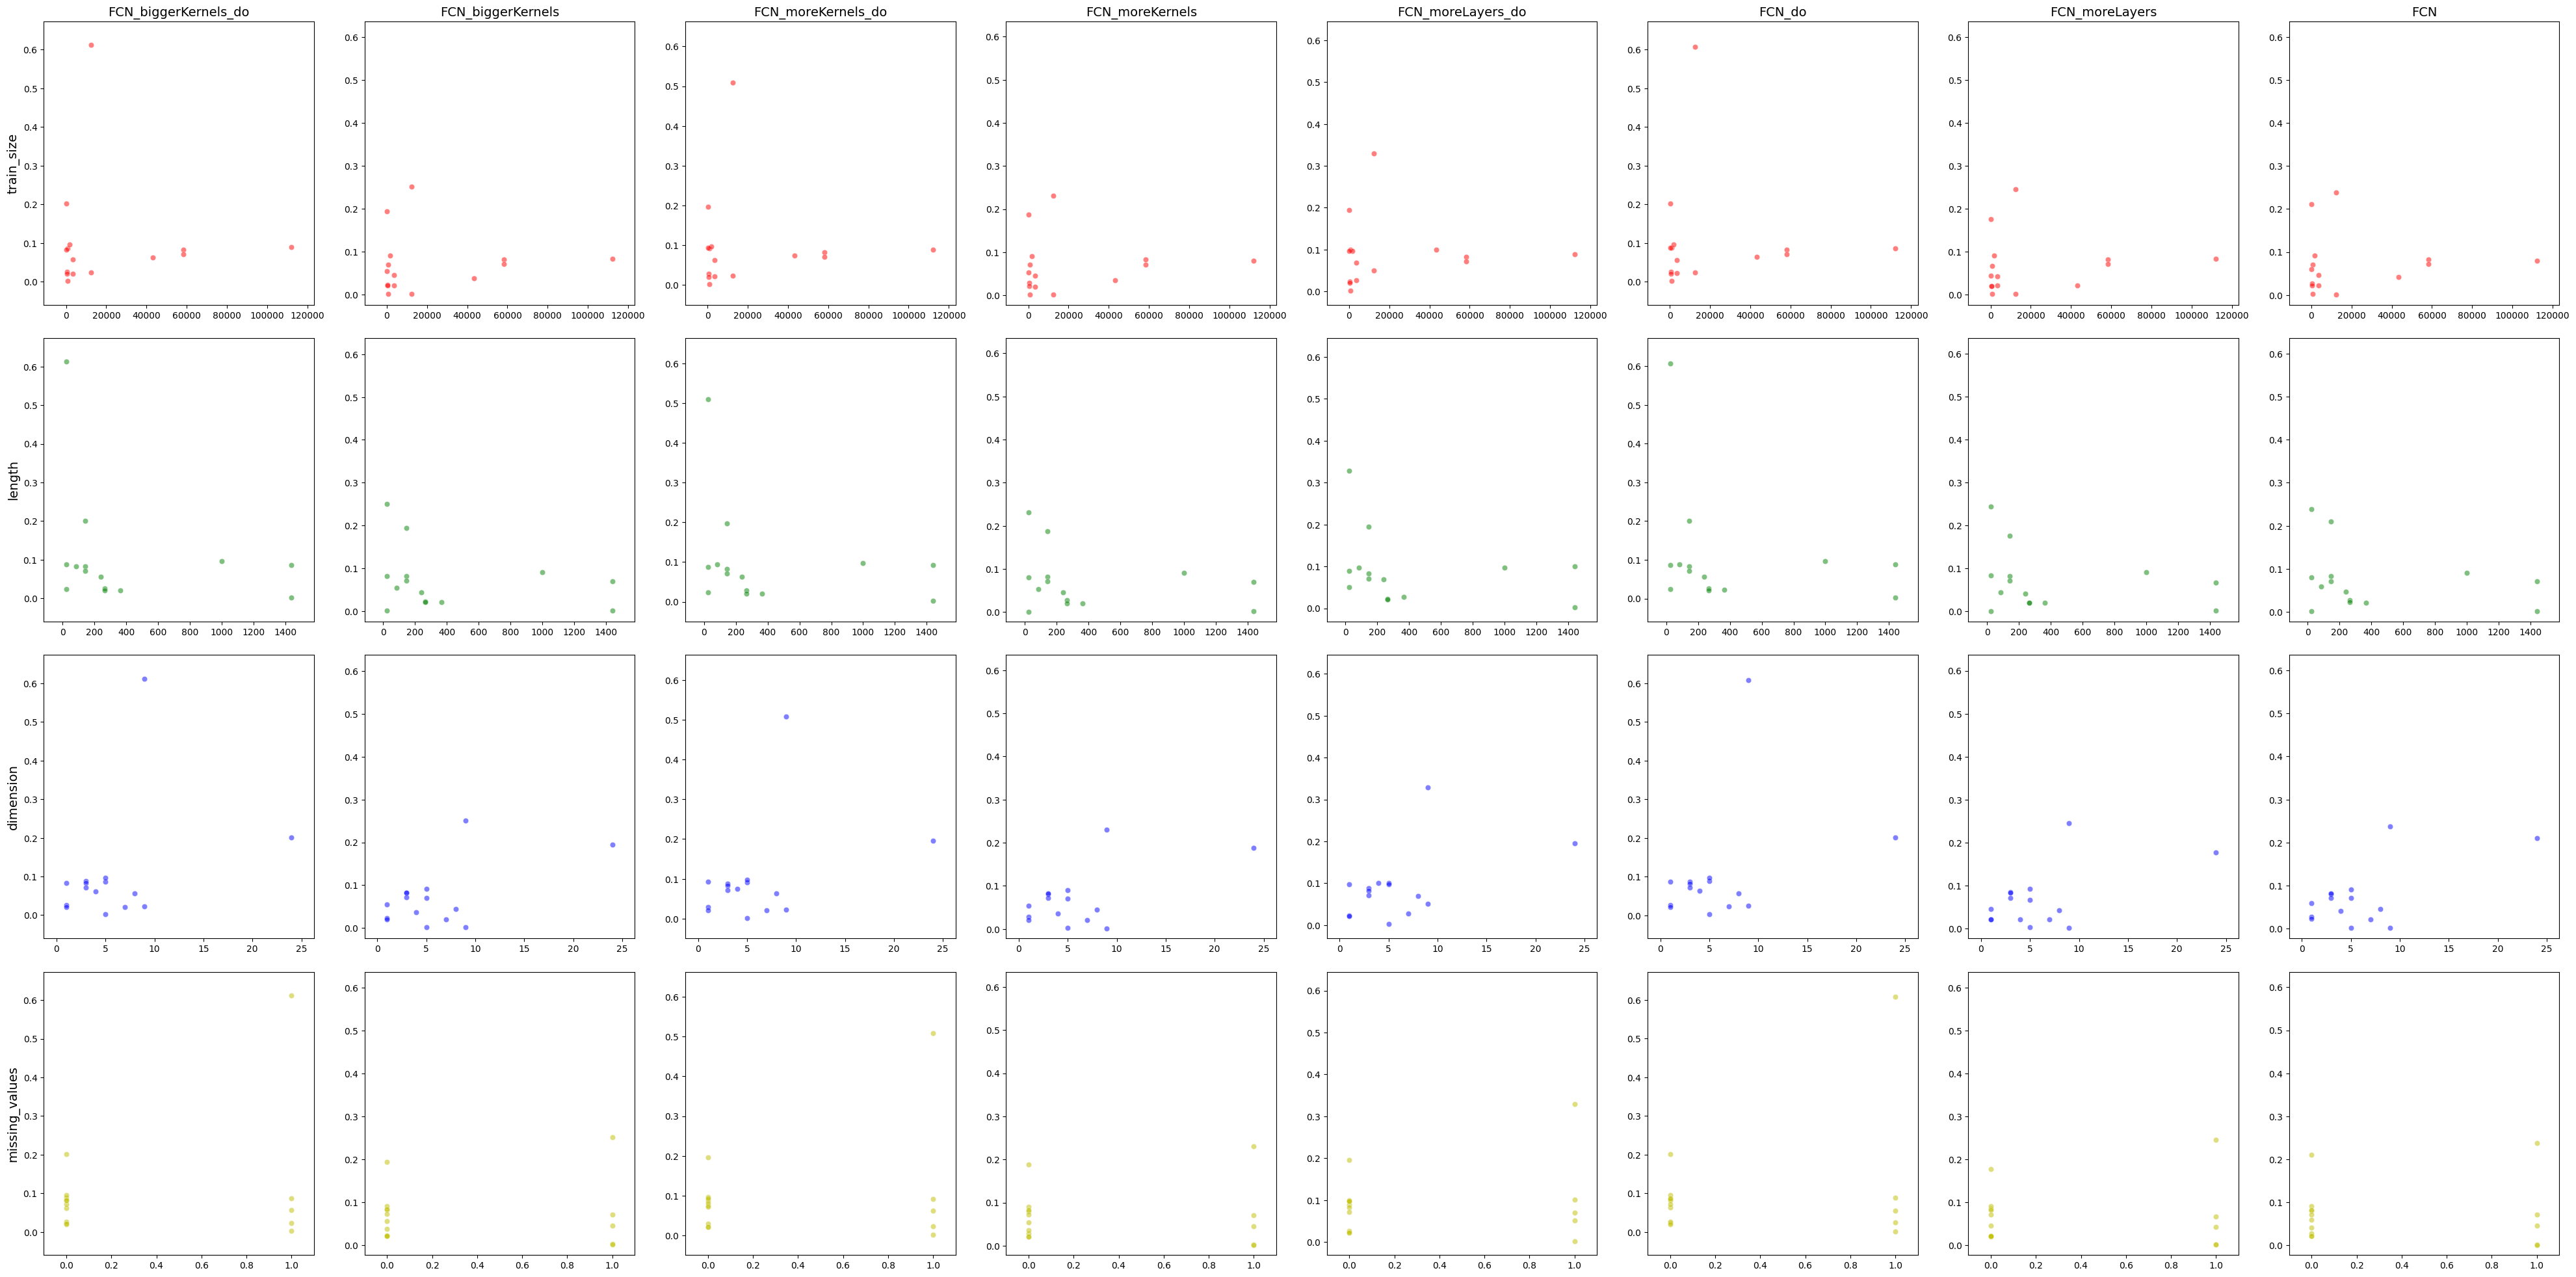

In [17]:
data = get_specific_metrics(metrics, znorm=False)
fig = meta_model_pair_plot(data, metadata_df, datasets_stats, same_y_scale=True)

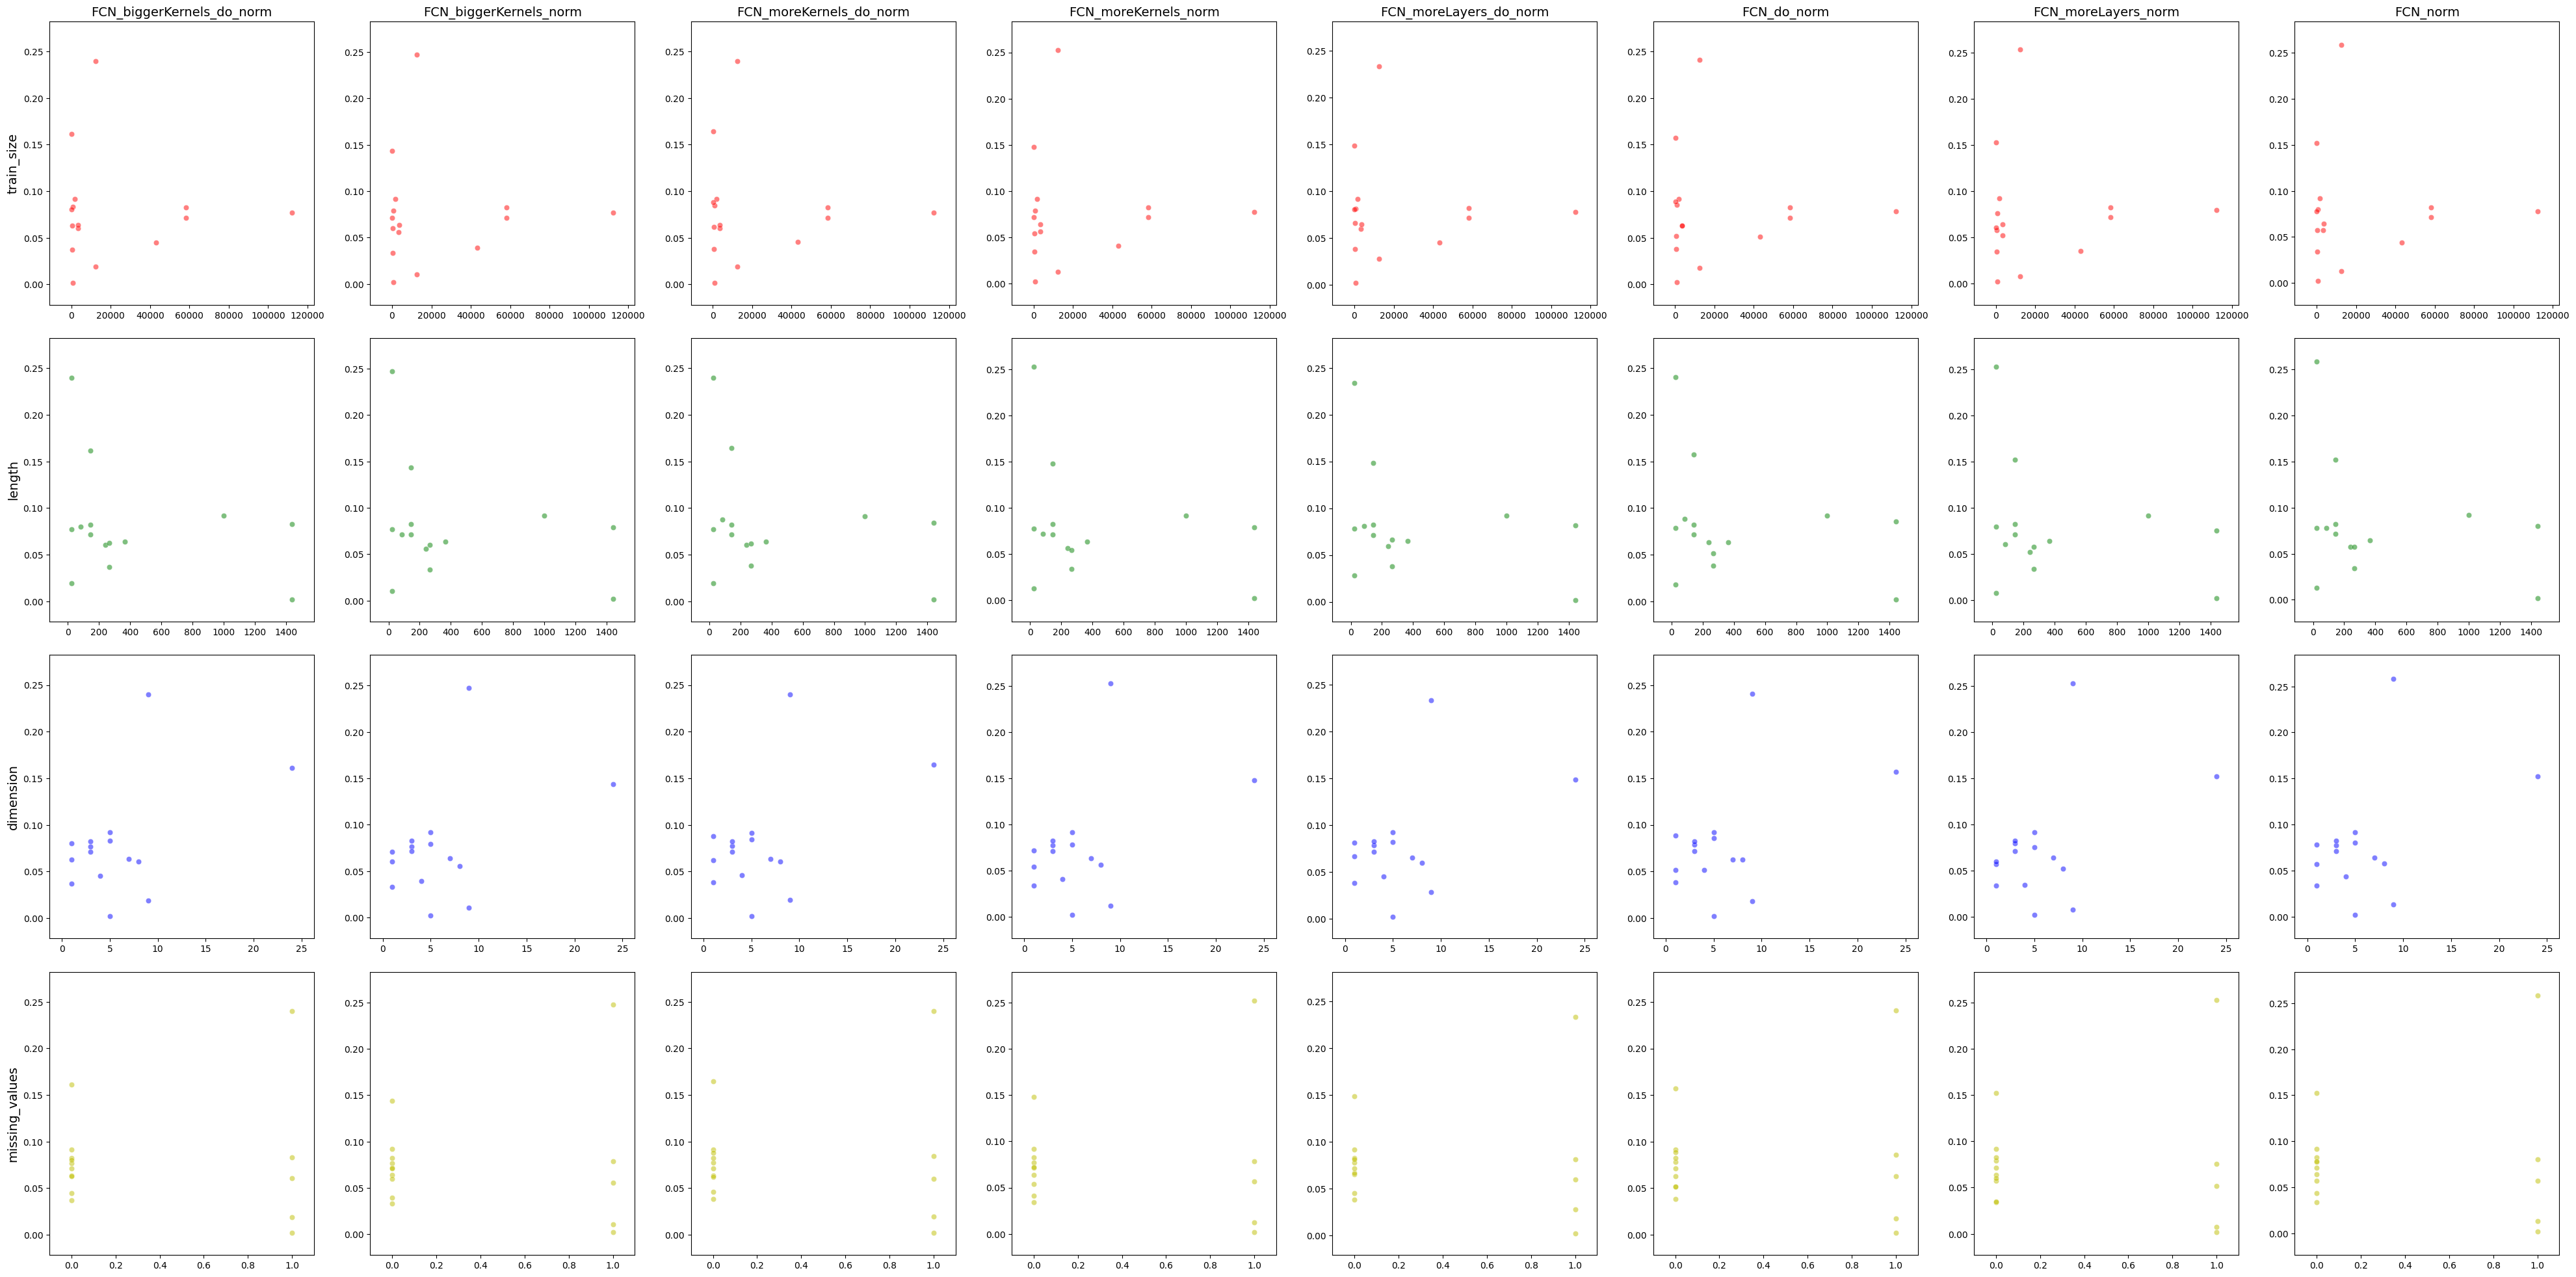

In [18]:
data = get_specific_metrics(metrics, znorm=True)
fig = meta_model_pair_plot(data, metadata_df, datasets_stats, same_y_scale=True)

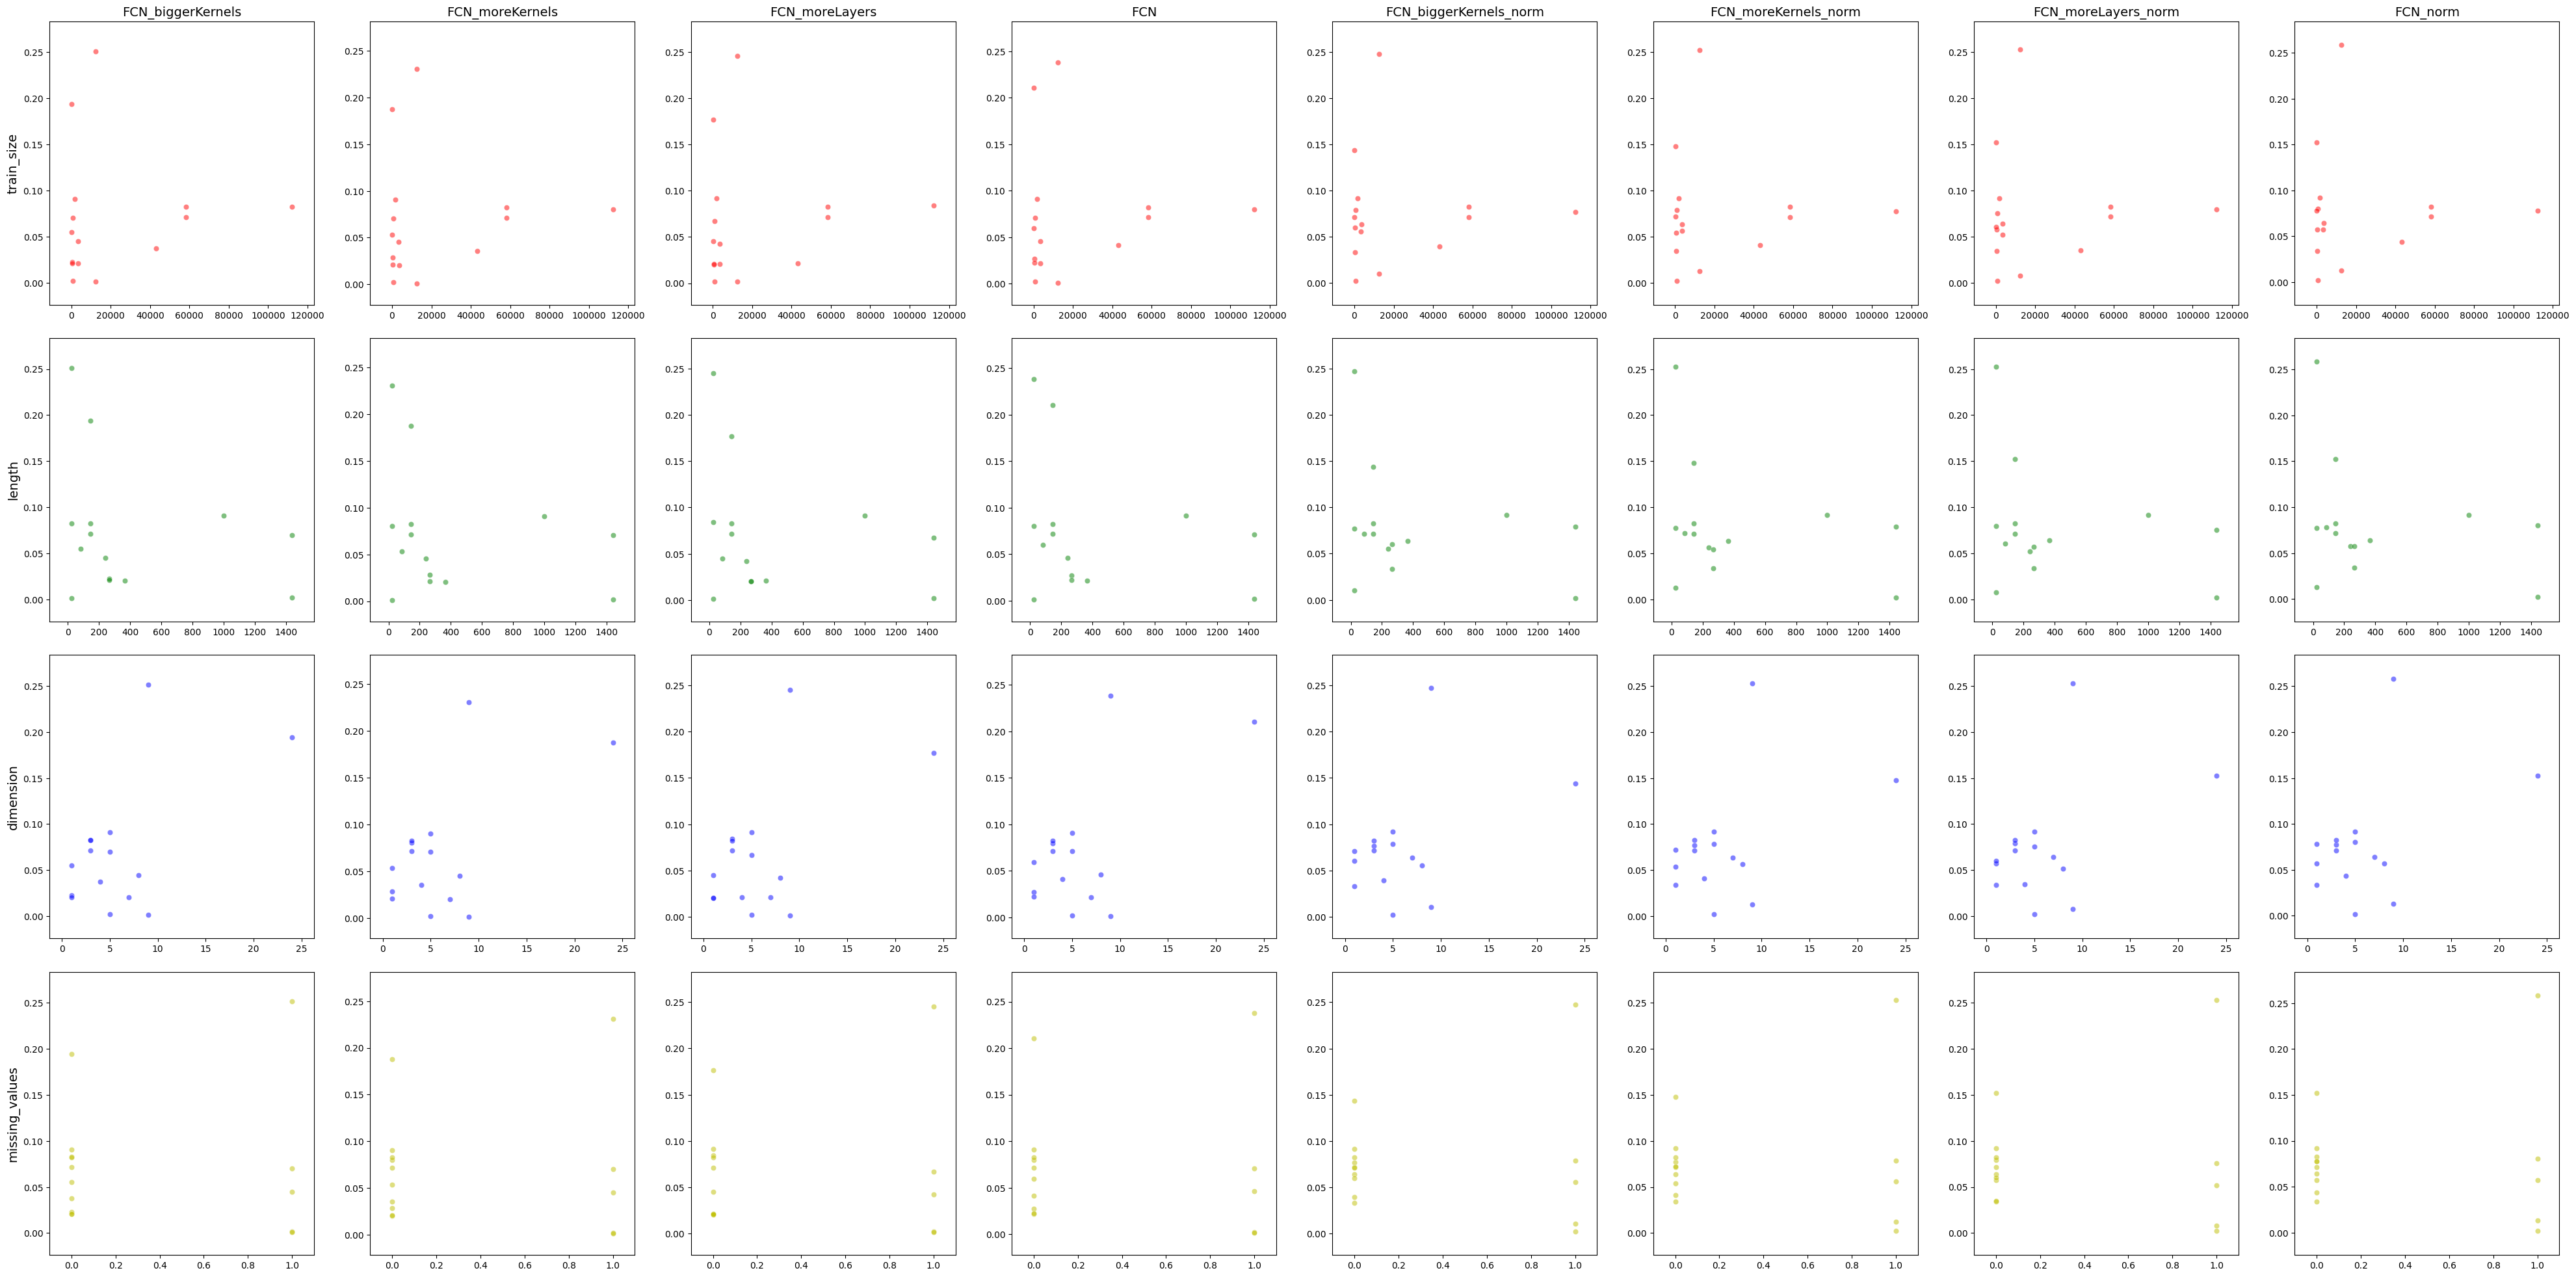

In [19]:
data = get_specific_metrics(metrics, dropout=False)
fig = meta_model_pair_plot(data, metadata_df, datasets_stats, same_y_scale=True)

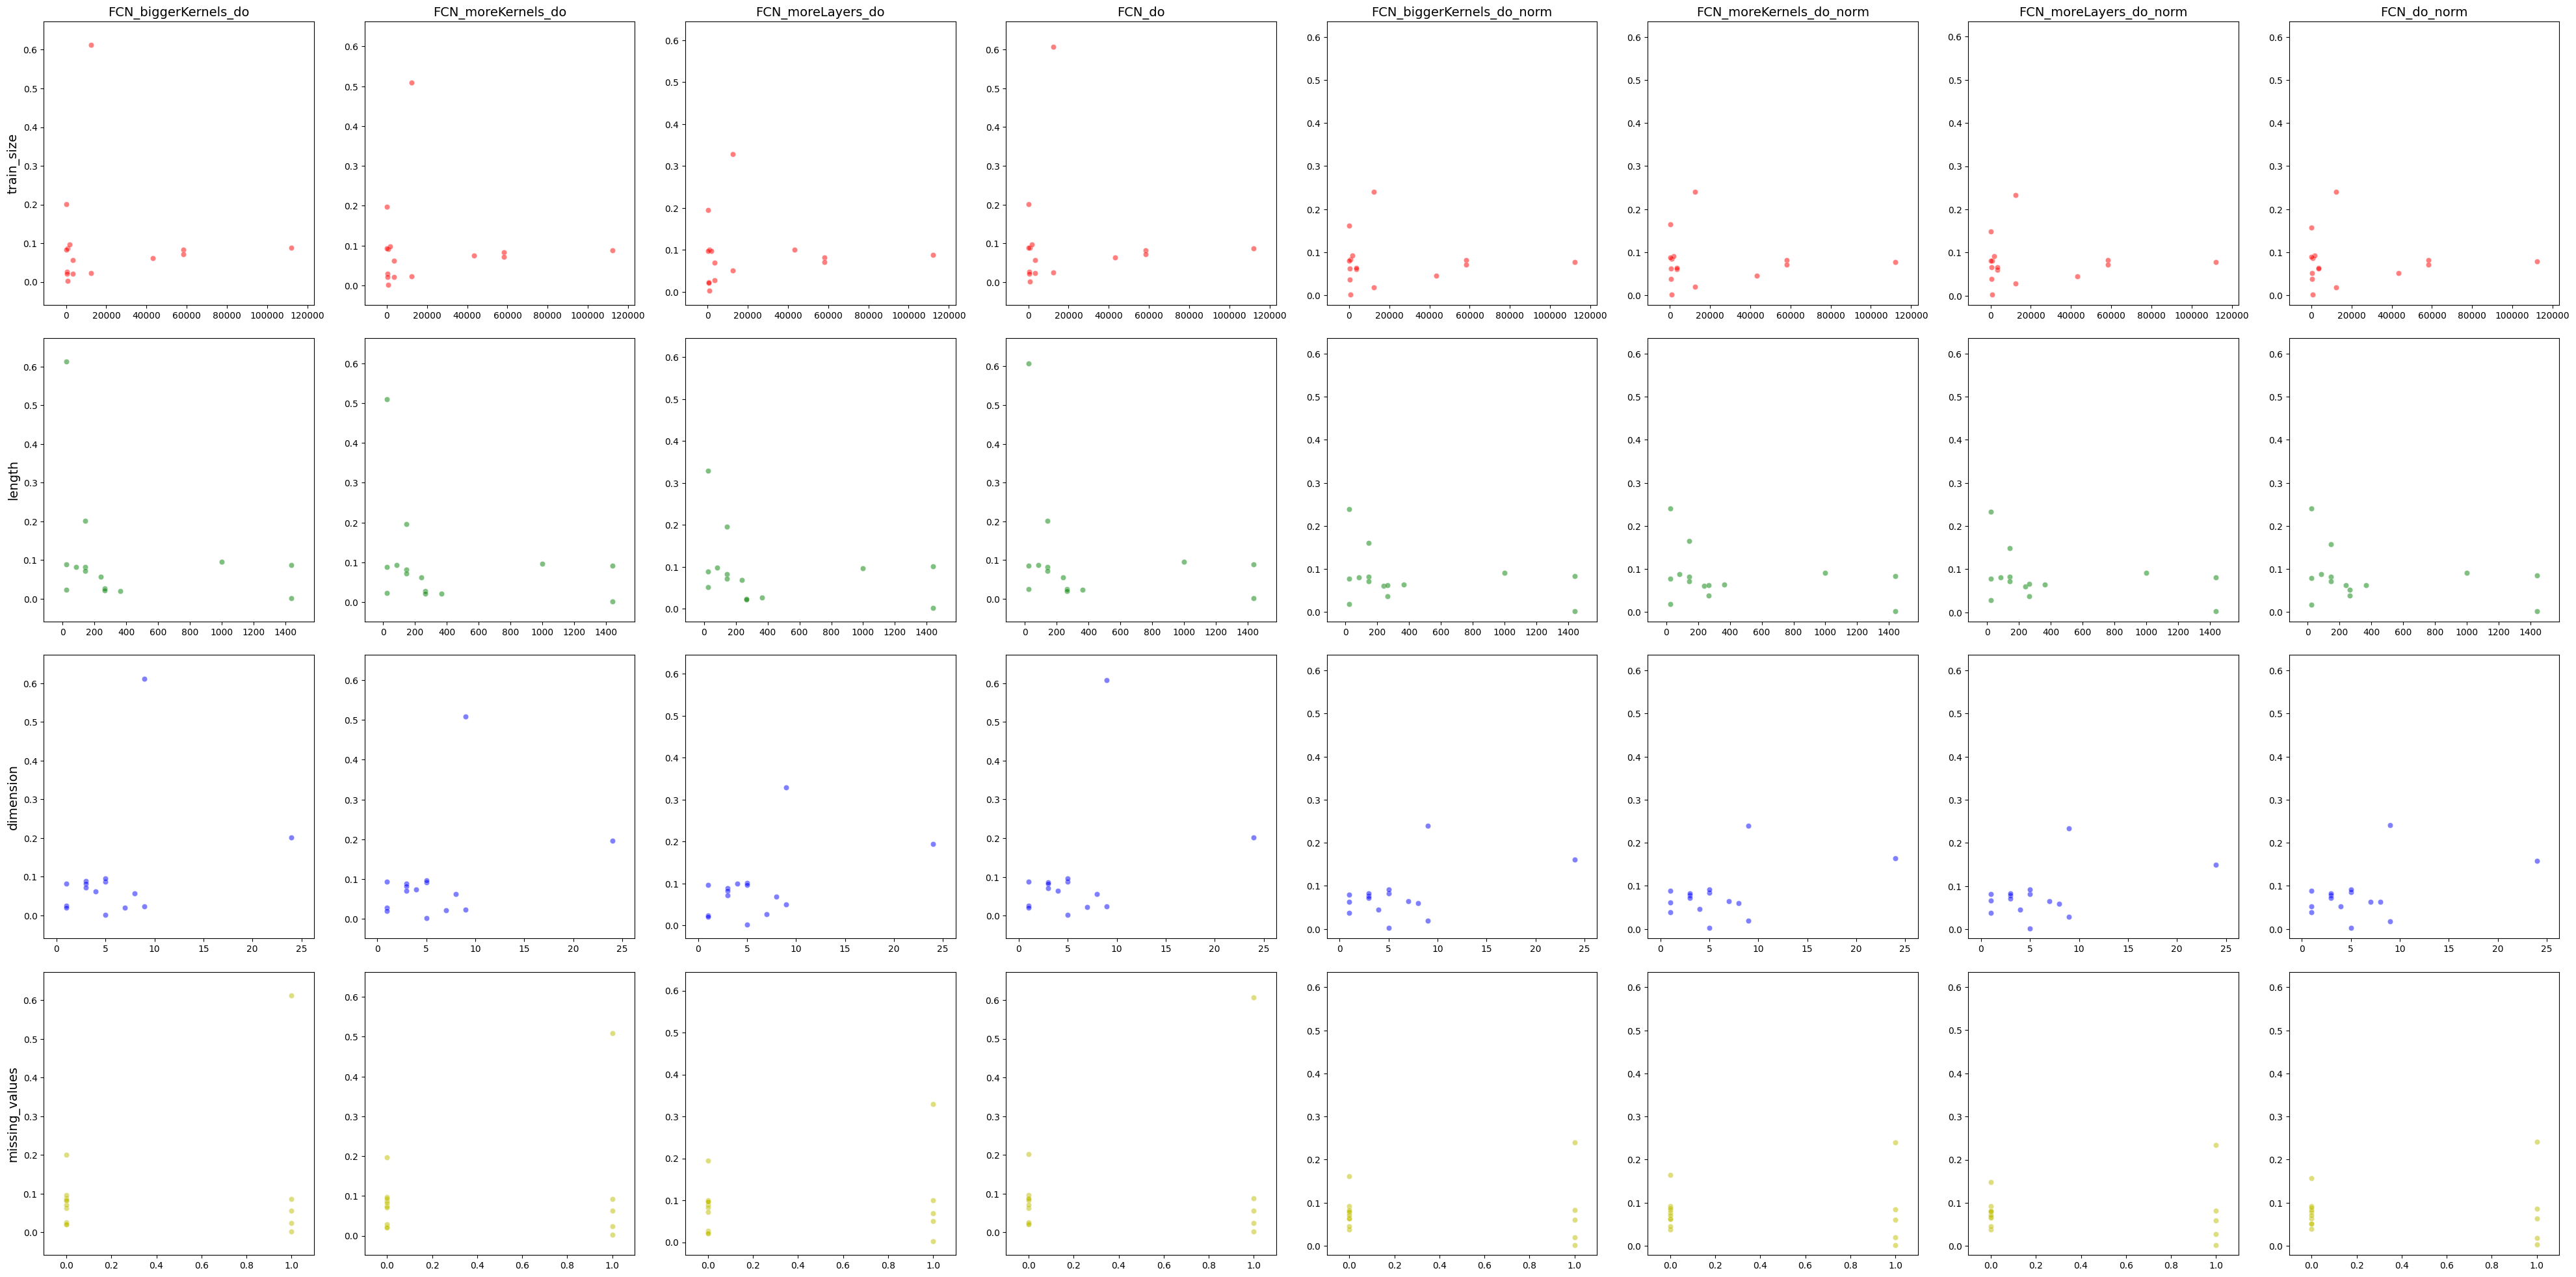

In [20]:
data = get_specific_metrics(metrics, dropout=True)
fig = meta_model_pair_plot(data, metadata_df, datasets_stats, same_y_scale=True)

### Dropout as factor

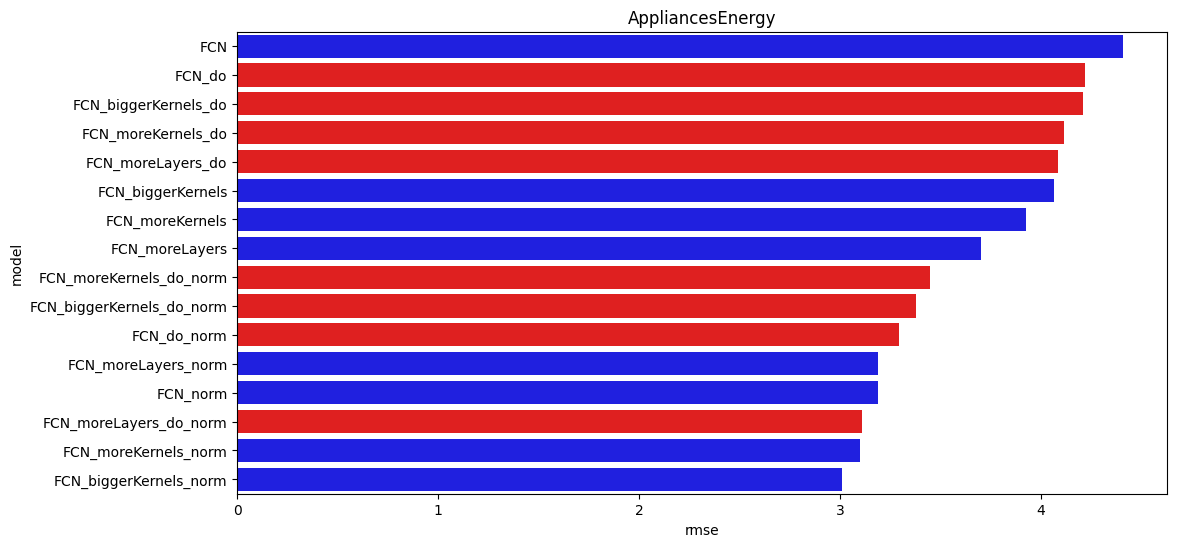

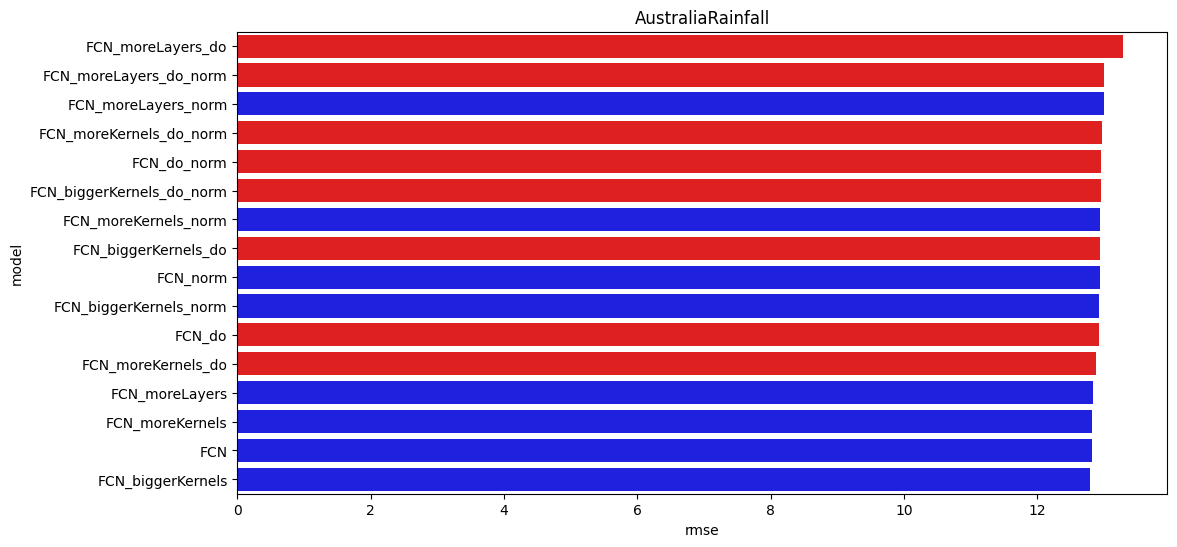

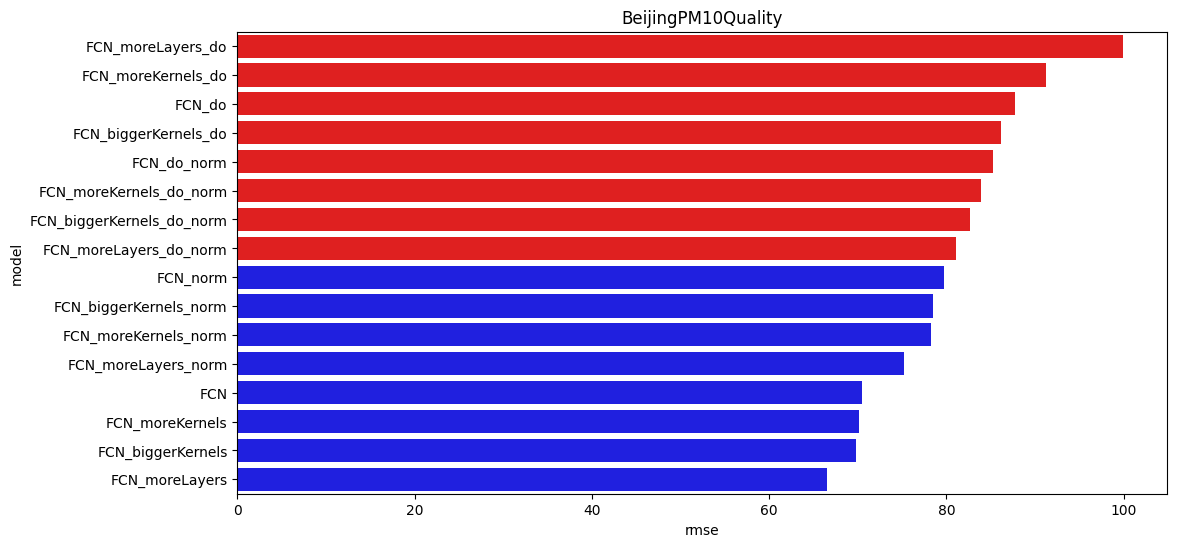

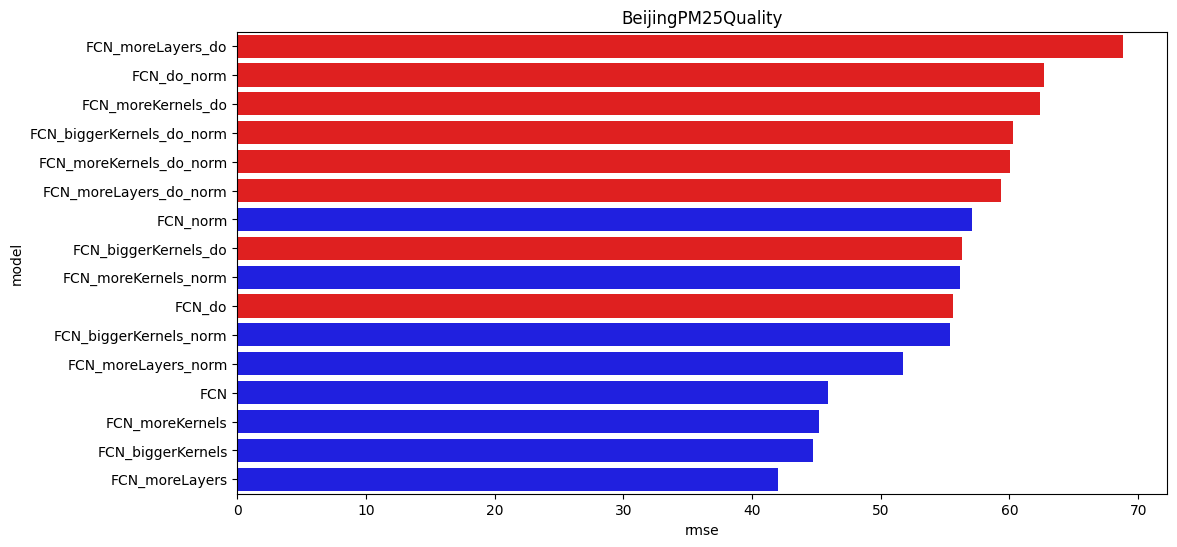

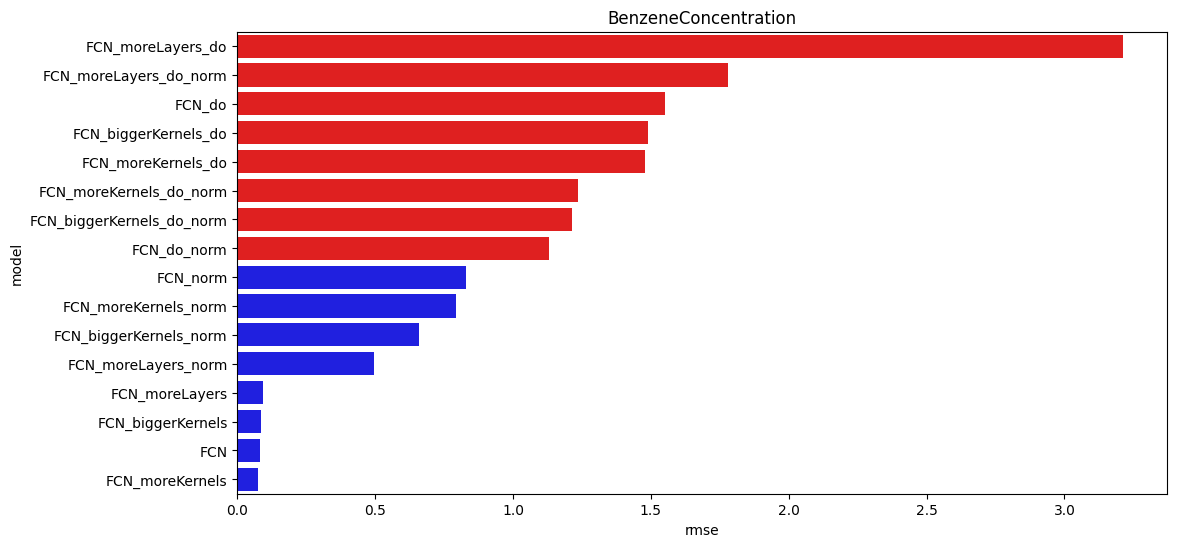

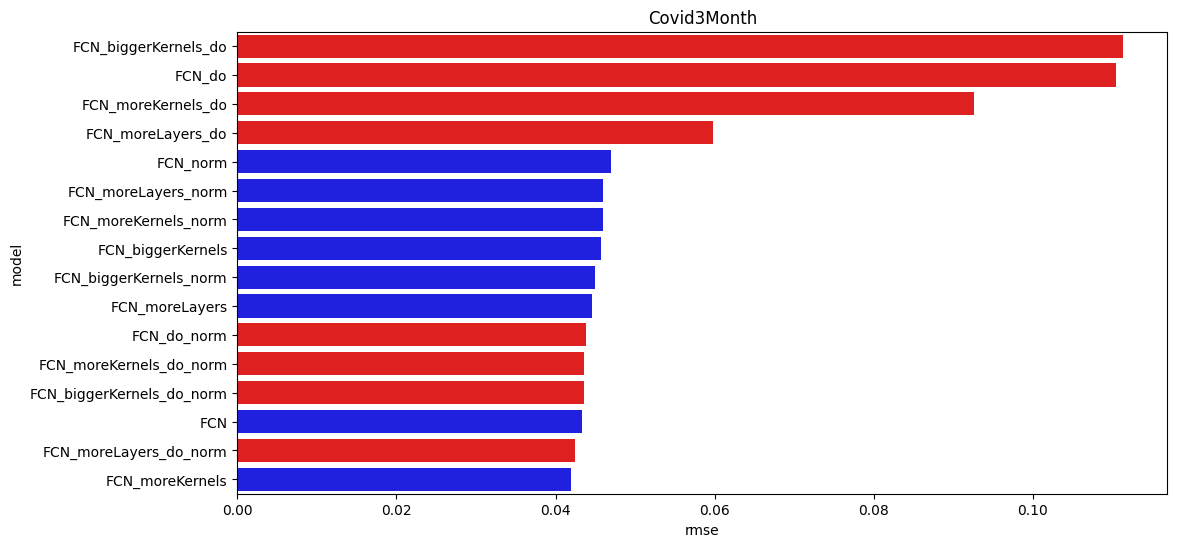

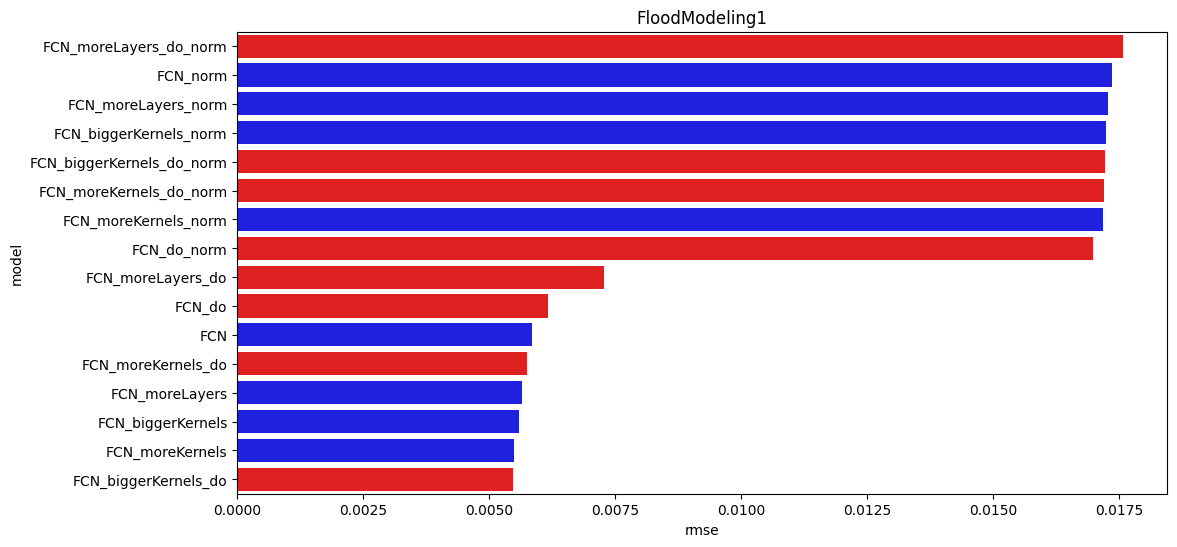

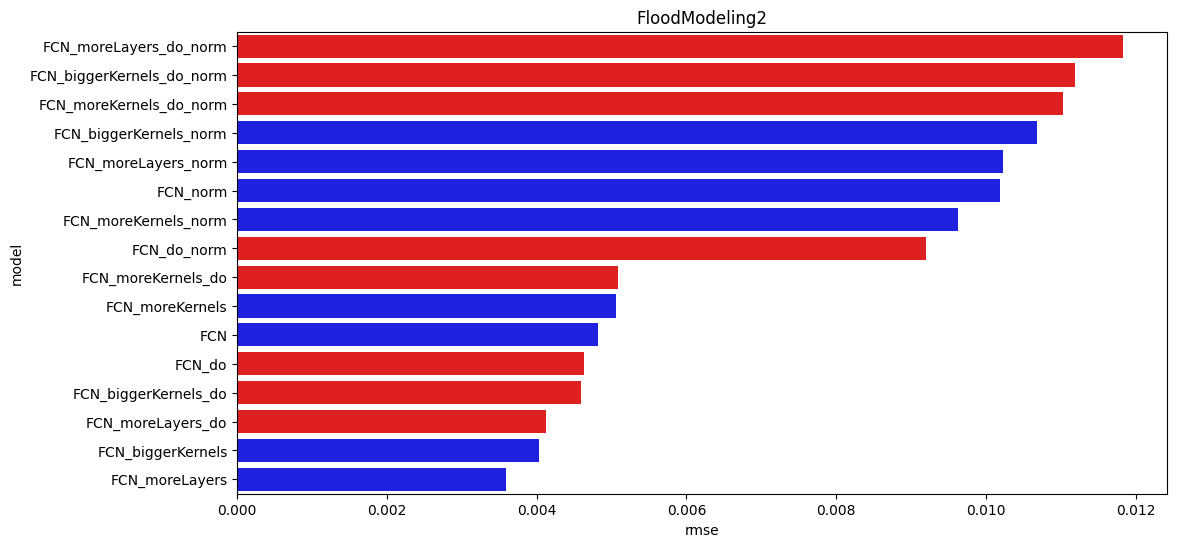

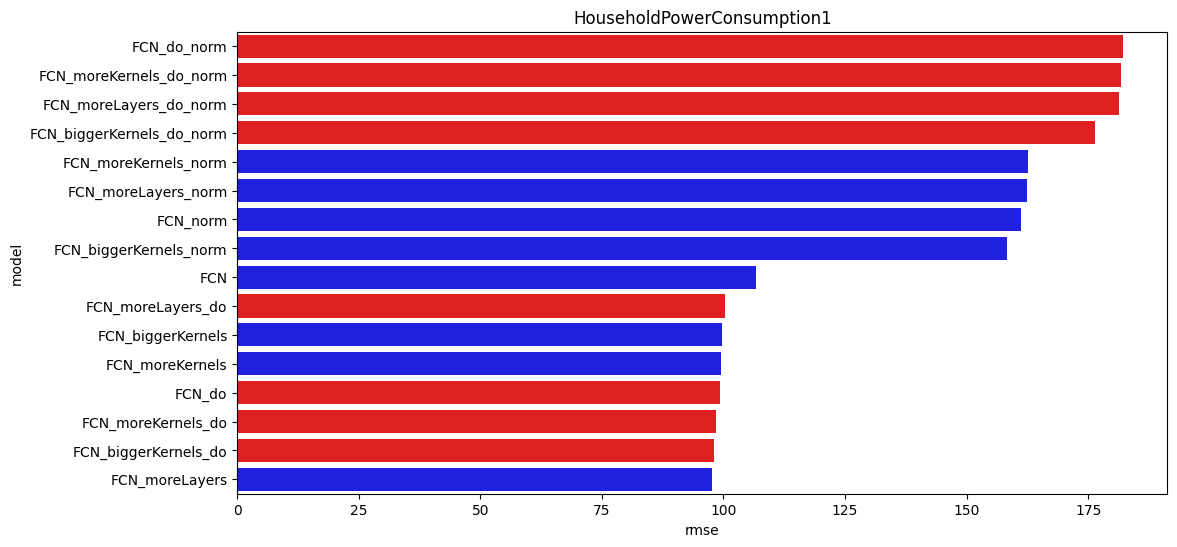

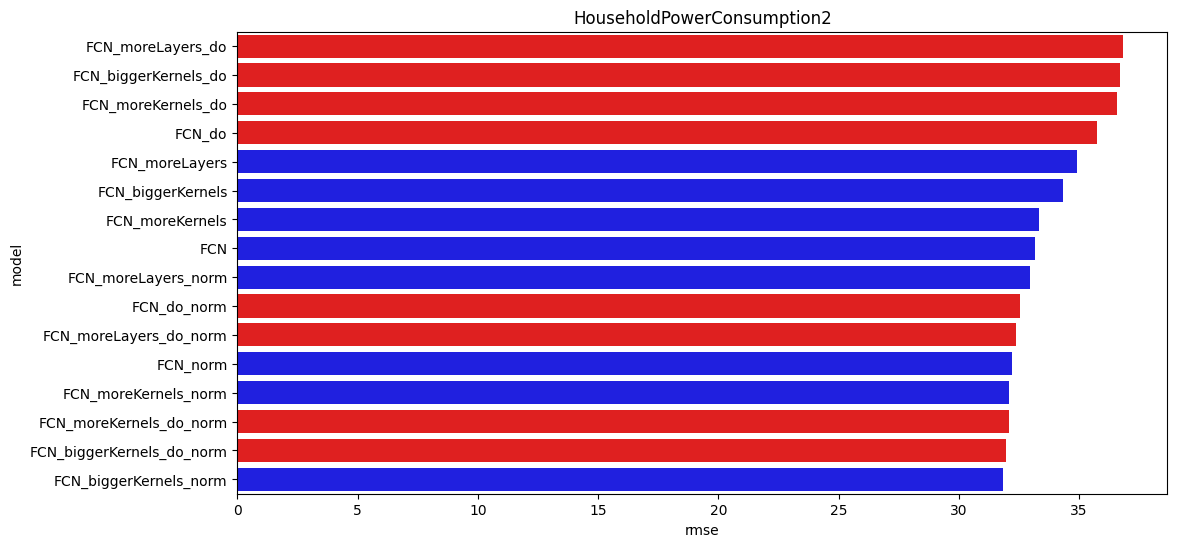

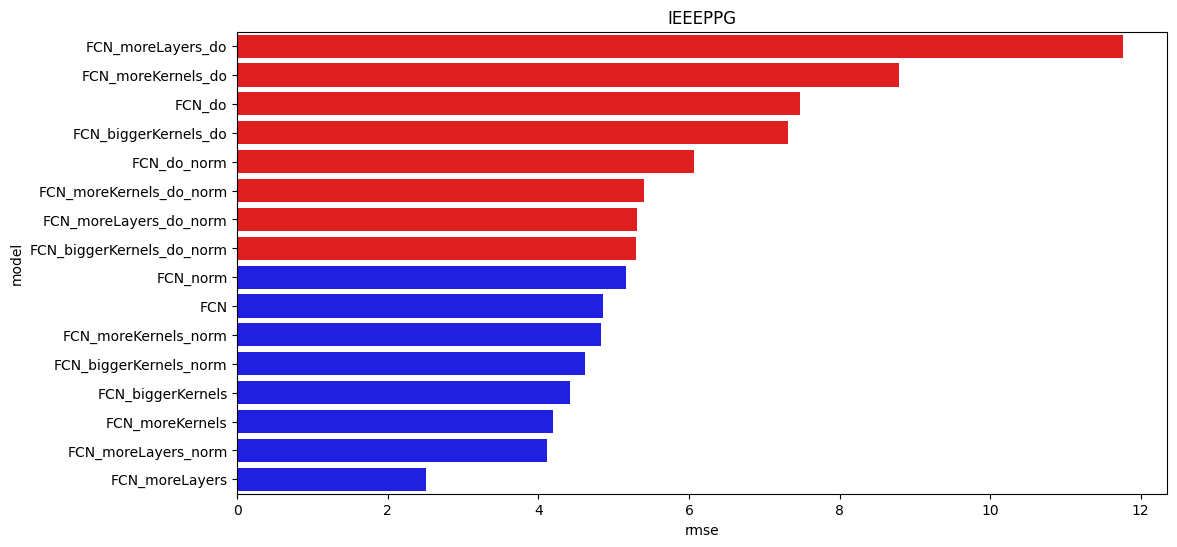

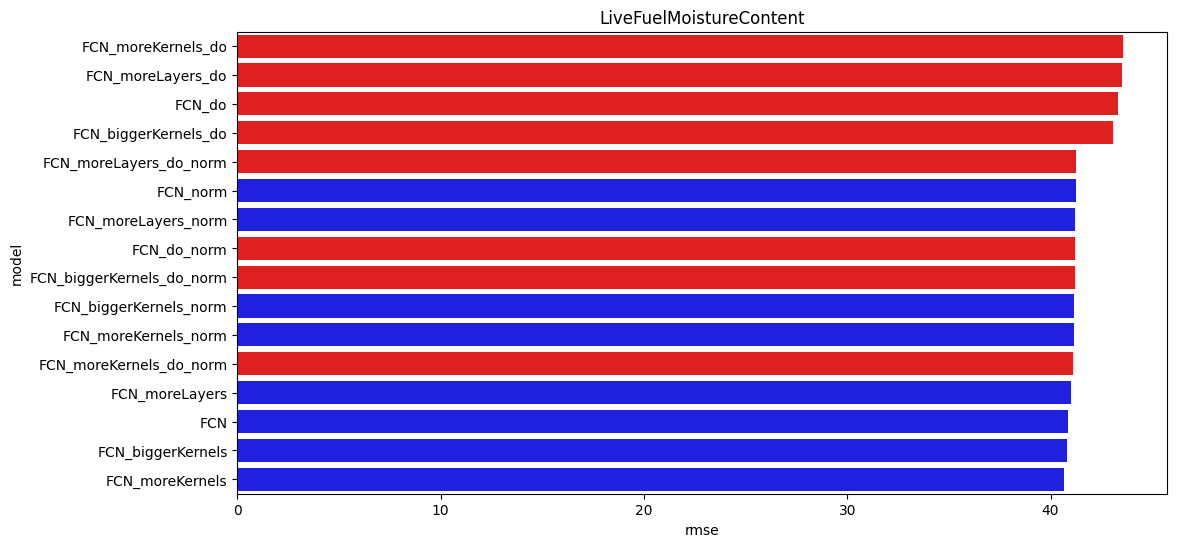

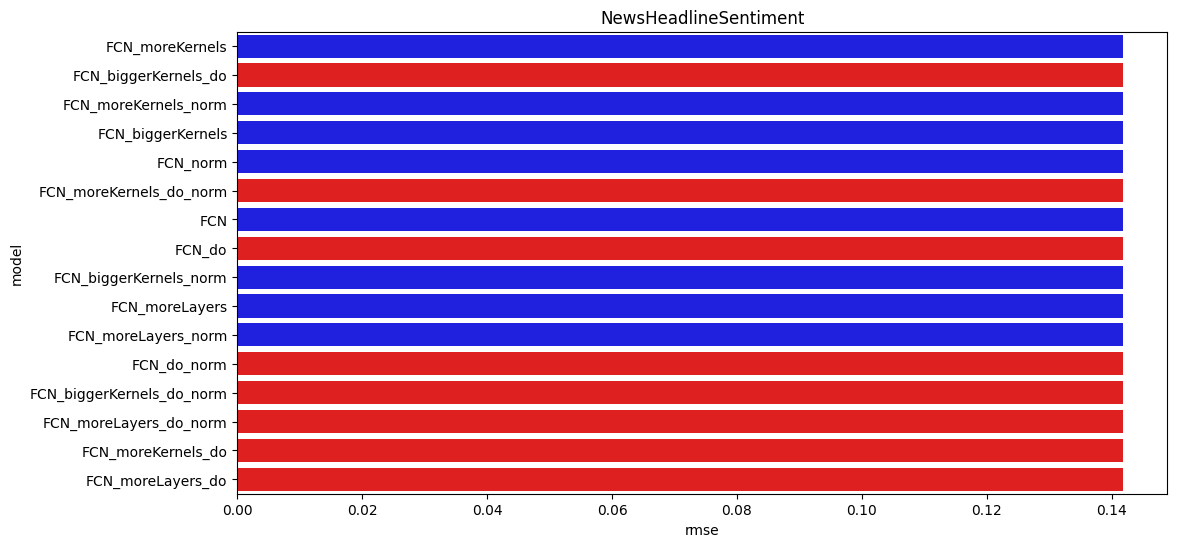

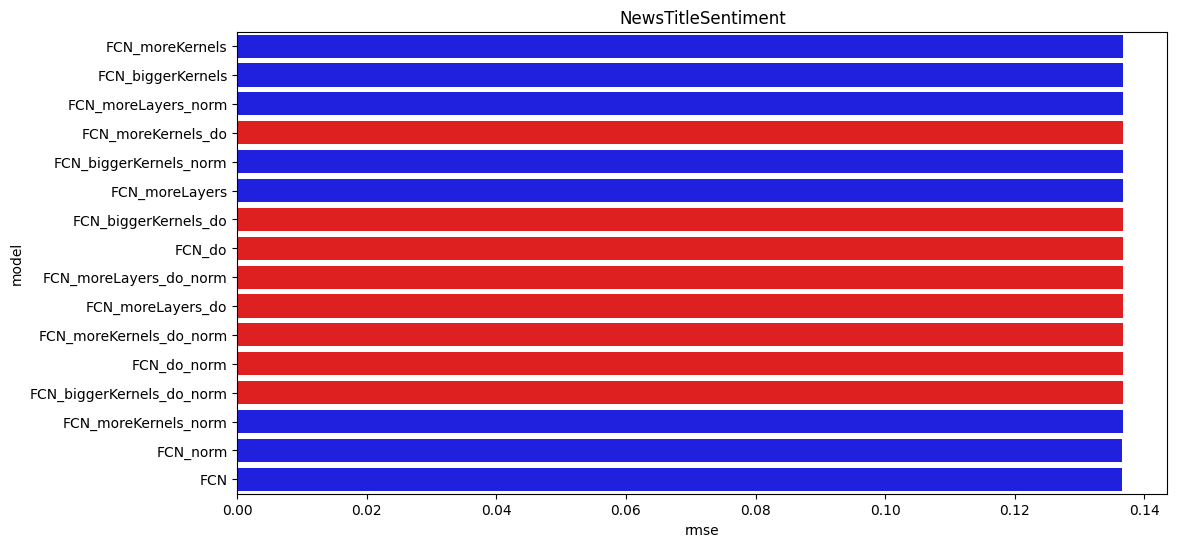

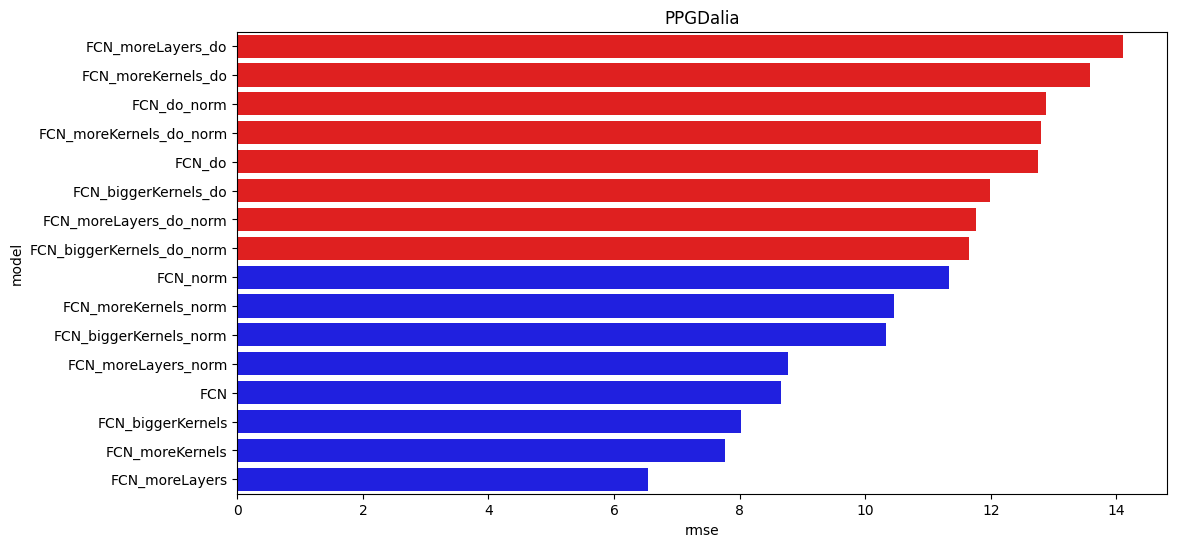

In [21]:
plot_rmse_per_dataset(metrics, '_do')

Dropout ganhou TODAS nos datasets abaixo. Talvez seja pela 'alta' dimensionalidade, em ordem:
- BenzeneConcentration (8)
- BeijingPM10Quality (9)
- BeijingPM25Quality (9)
- IEEEPPG (5)
- PPGDalia (4)

Resto dos metadados são muito diferentes.

No entanto, outros datasets com 'alta' dimensionalidade não foram tão discrepantes:
- LiveFuelMoistureContent (7)
- AppliancesEnergy (24)
- HouseholdPowerConsumption1 (5)
- HouseholdPowerConsumption2 (5)

### Znorm as factor

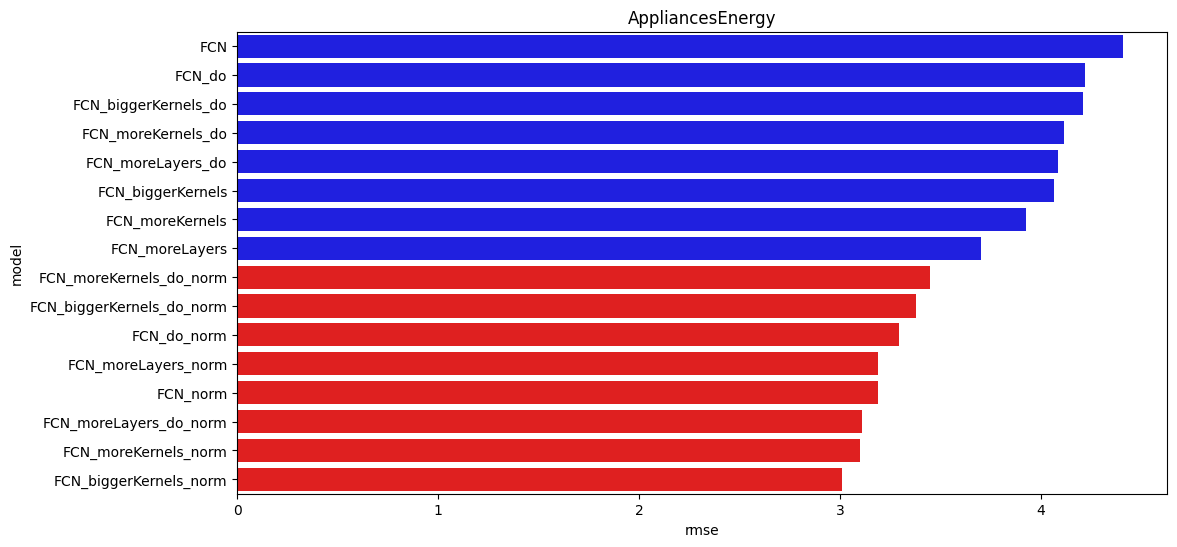

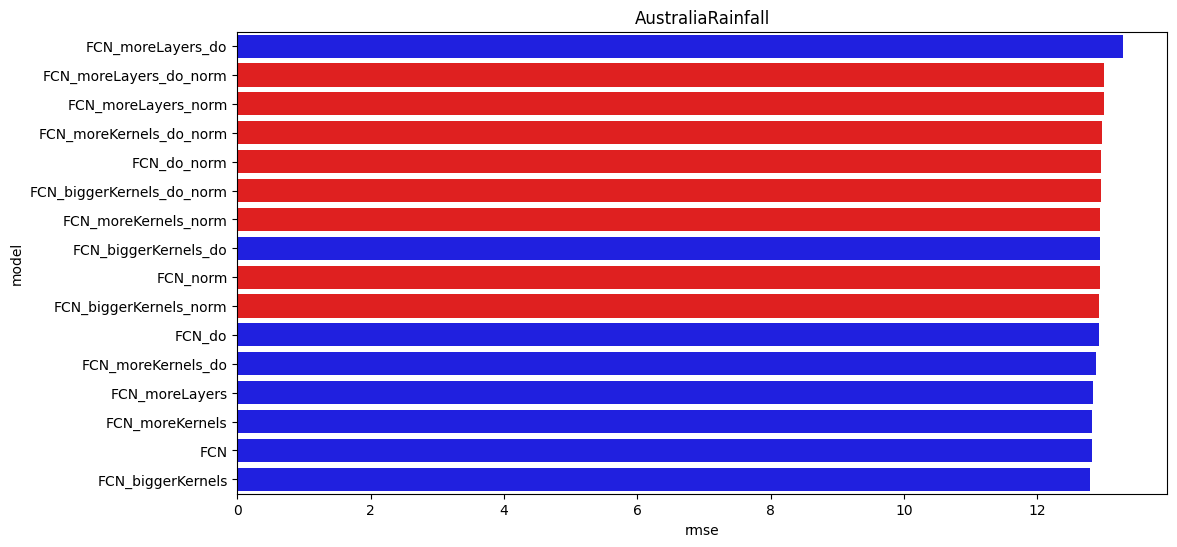

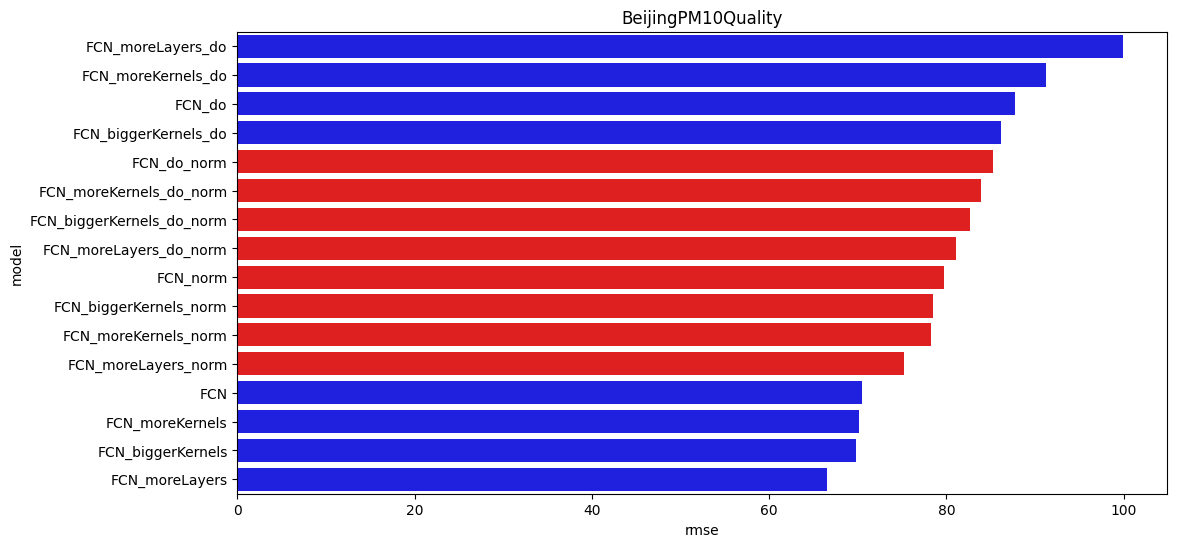

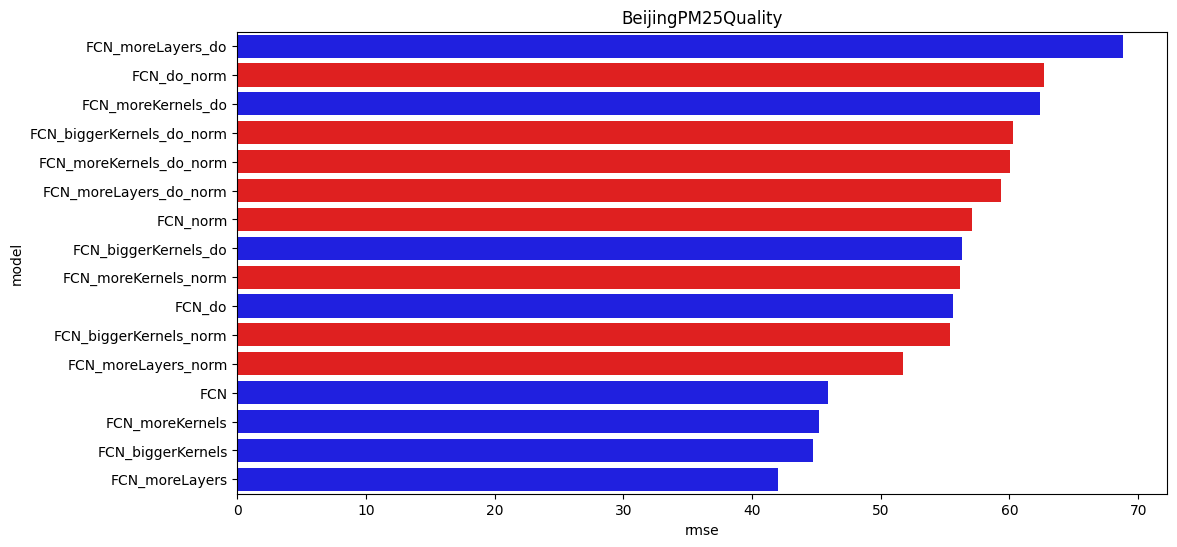

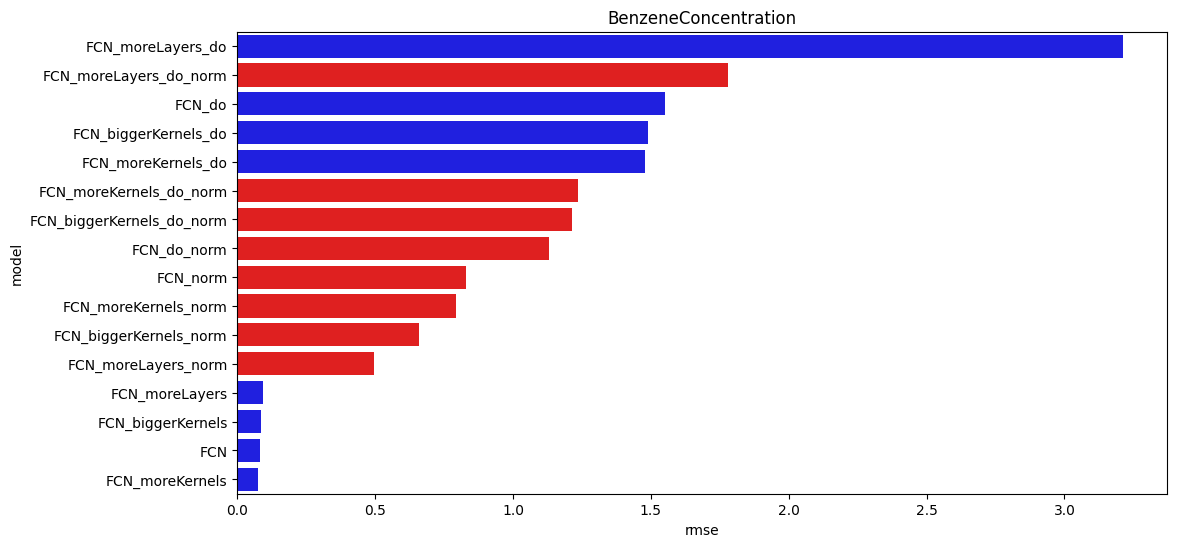

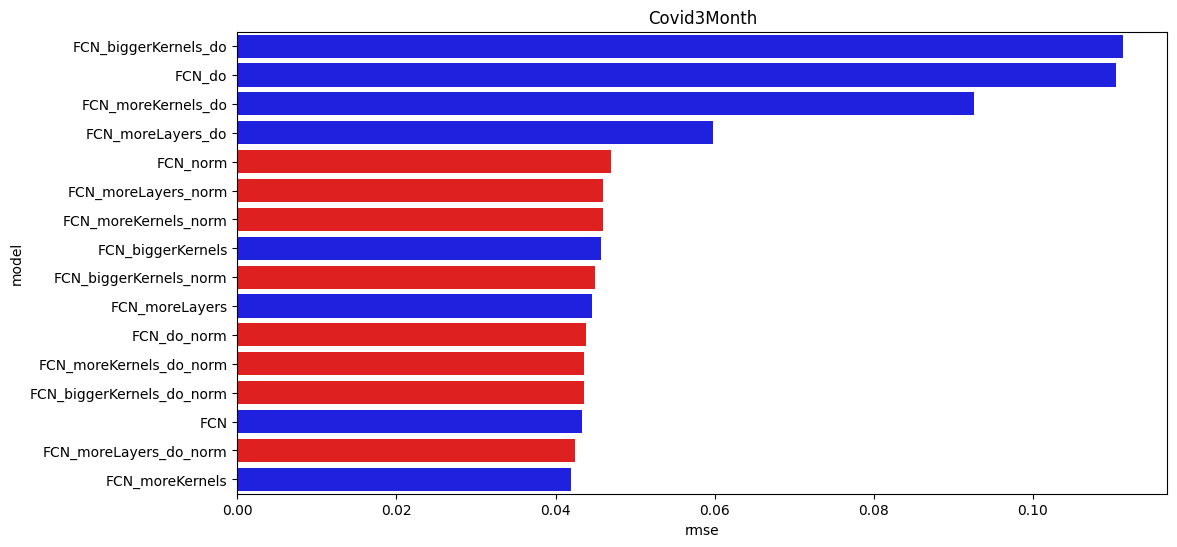

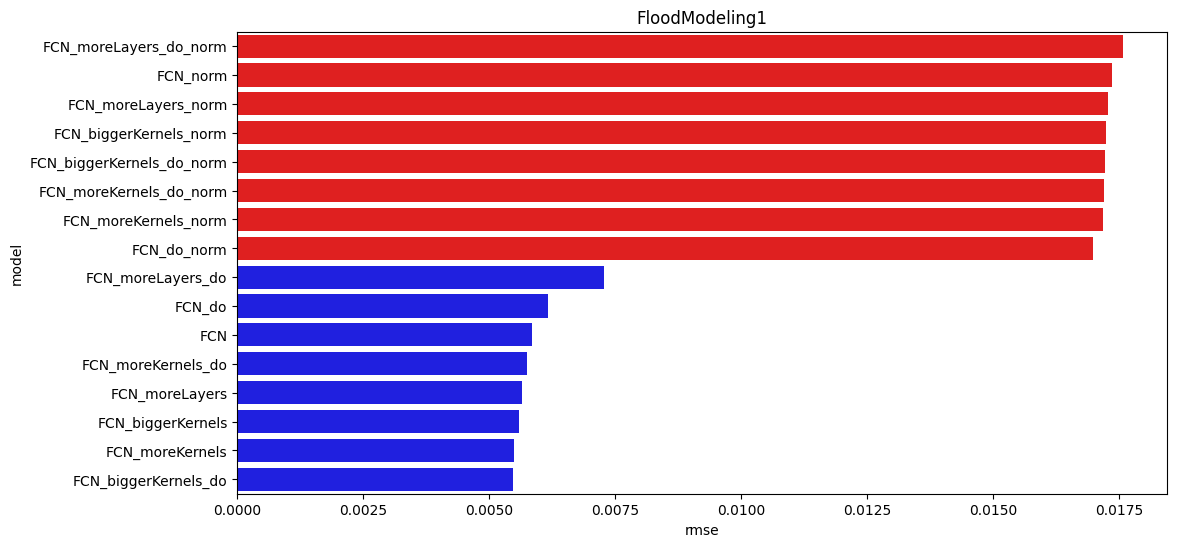

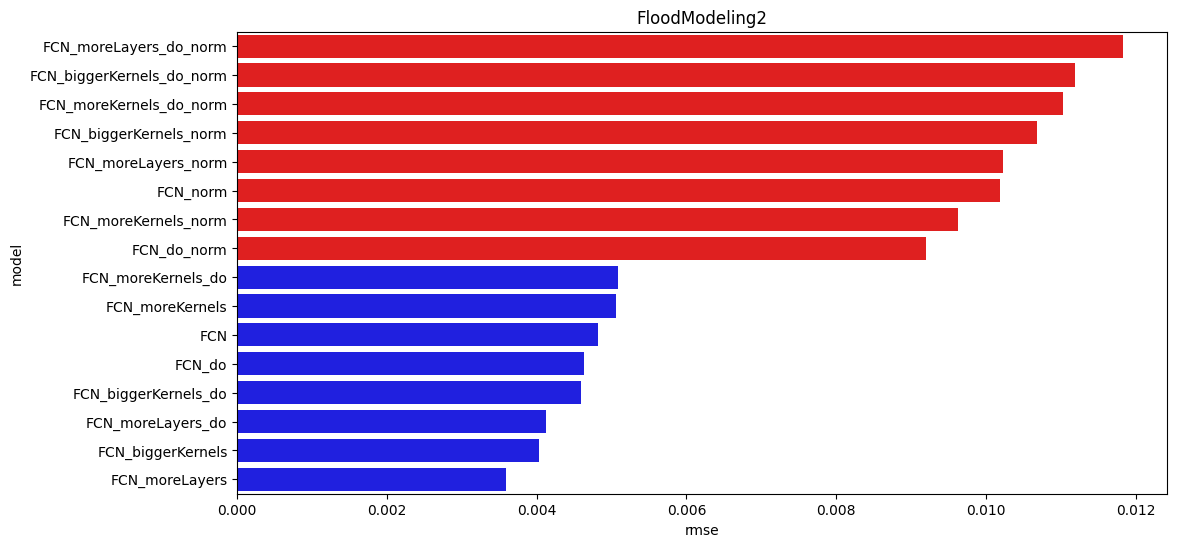

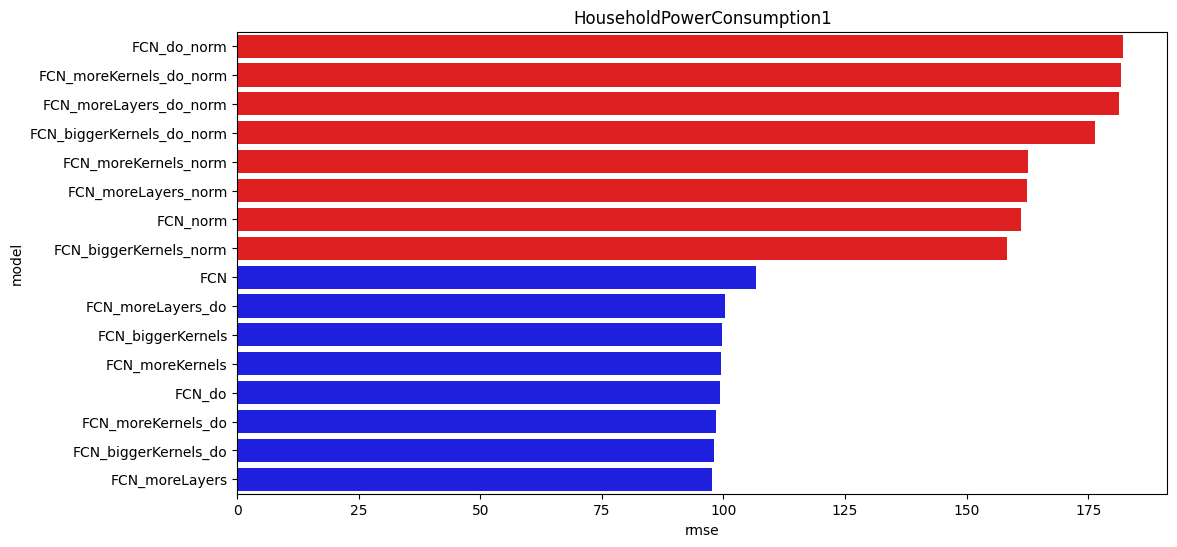

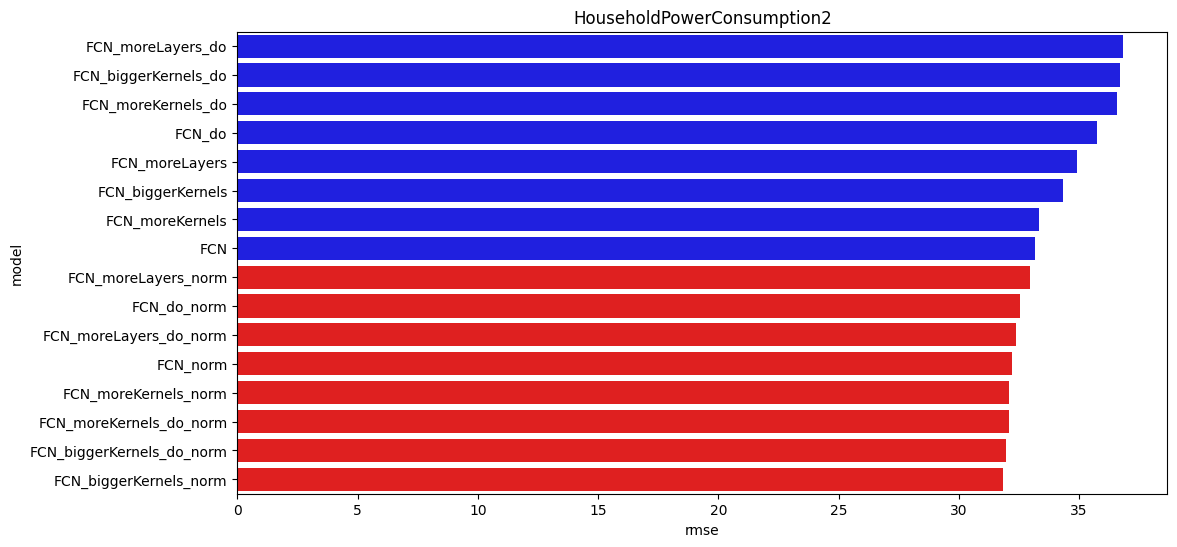

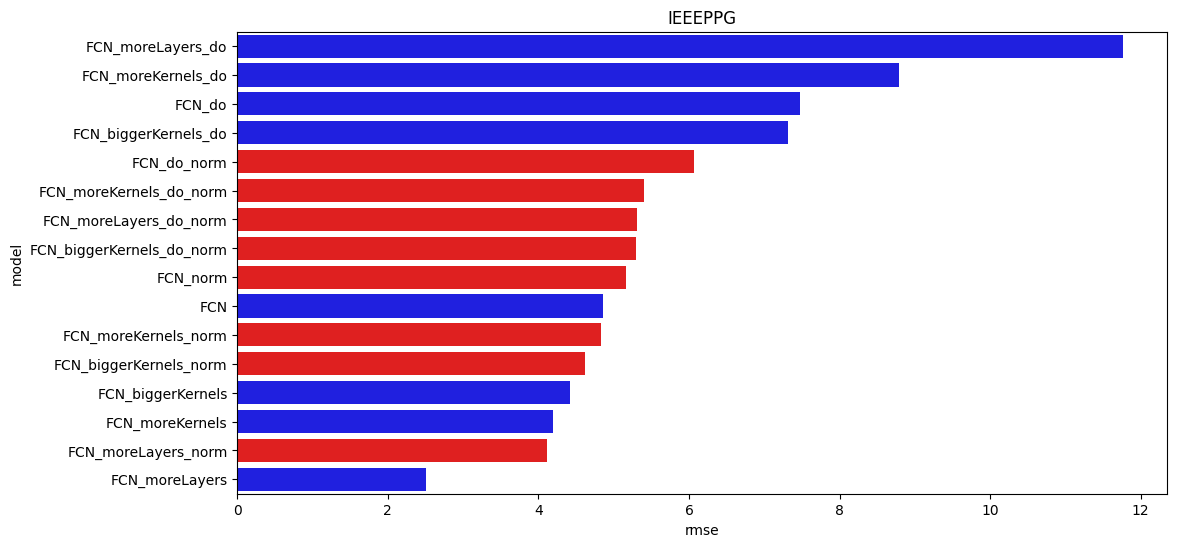

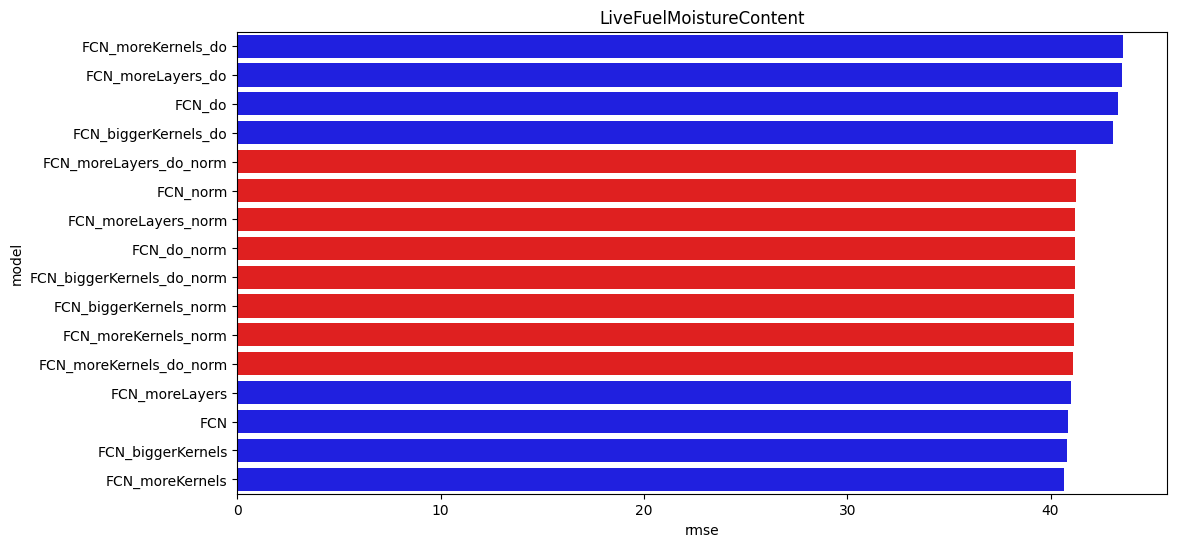

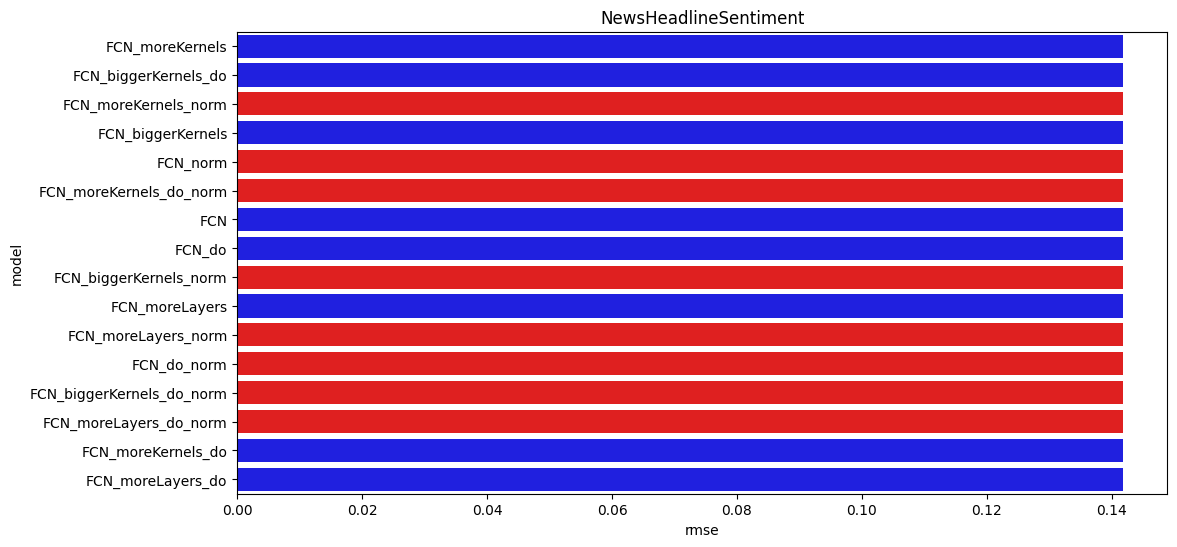

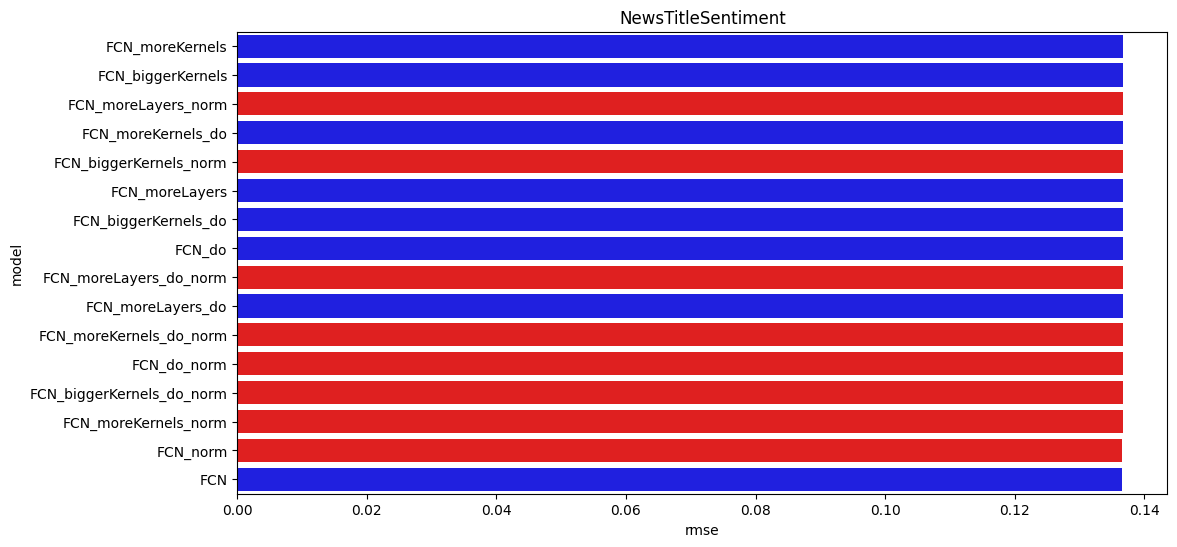

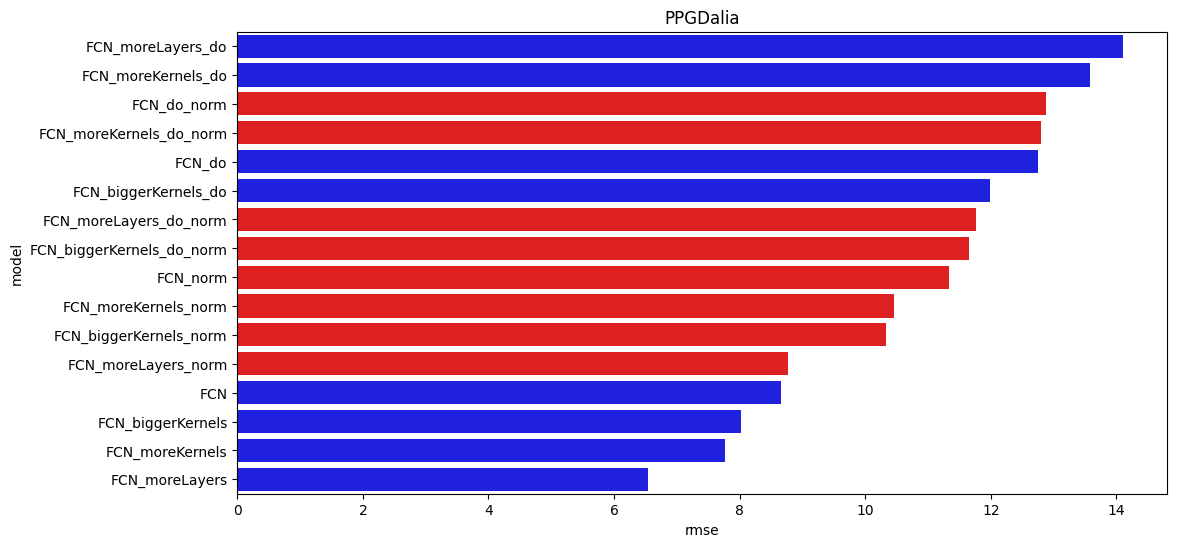

In [22]:
plot_rmse_per_dataset(metrics, '_norm')

IMPOSSÍVEL, pois HouseholdPowerConsumption1 possuem os mesmos metadados e são opostos!
